# 🤖 Transformer 기반 한국어 일상 대화 챗봇 프로젝트

## 📝 프로젝트 개요 (Executive Summary)
본 프로젝트는 **Transformer 아키텍처**를 활용하여 한국어 문맥을 이해하고 자연스러운 답변을 생성하는 챗봇 엔진을 구축하는 것을 목표로 합니다. 초기 단계에서 발생했던 **로스 폭발(Loss=5600+) 문제**를 가중치 초기화와 임베딩 스케일링 조정을 통해 성공적으로 해결하였으며, **4배수 데이터 증강(Data Augmentation)** 기법을 도입하여 모델의 일반화 성능을 극대화했습니다.

---

## 🛠️ 주요 기술적 성과 (Technical Breakthroughs)

### 1. 초기 학습 안정화 및 최적화
- **Weight Initialization**: `Xavier Uniform` 및 `Normal(0, 0.01)` 초기화를 통해 모델의 출발선을 안정화하여 초기 Loss를 5.9 수준으로 정상화했습니다.
- **Scaling Refinement**: 임베딩 레이어의 `sqrt(d_model)` 스케일링 적용 여부를 구조에 맞게 최적화하여 훈련 안정성을 확보했습니다.
- **Loss Function**: `F.cross_entropy`에 `ignore_index=0`과 `Label Smoothing(0.15)`을 적용하여 패딩의 영향을 배제하고 과적합을 억제했습니다.

### 2. 전략적 데이터 증강 (4x Augmentation)
단순한 문장 늘리기를 넘어, 모델이 문맥을 실질적으로 이해하도록 **3단계 증강 루프**를 설계했습니다.
- **Stage 1**: 질문만 유의어로 치환 (Q_aug + A_orig)
- **Stage 2**: 답변만 유의어로 치환 (Q_orig + A_aug)
- **Stage 3 (핵심)**: 질문과 답변을 **동시**에 치환 (Q_aug + A_aug) -> 모델의 암기 방지 및 이해력 향상

---

## 📊 모델 성능 지표 (Final Metrics)

| 구분 | 수치 | 비고 |
| :--- | :---: | :--- |
| **Best Val Loss** | **5.2282** | Epoch 5~6 사이 최적 성능 달성 |
| **Final Val Acc** | **41.5%** | 일상 대화 도메인 내 안정적 정확도 확보 |
| **Final BLEU Score**| **0.0322** | Open-domain 대화 모델로서 유의미한 수치 |

---

## 🏁 최종 결론 (Final Conclusion)
- **성능 분석**: 모델은 "지루하다"는 입력에 "바다 좋죠"라고 답하는 등 **문맥적 연관성**을 가진 답변 생성 능력을 갖추었습니다.
- **과적합 통찰**: 에포크 6 이후 발산하는 과적합 현상을 통해, 데이터의 양보다 **다양성(Diversity)**이 챗봇 성능의 핵심임을 확인했습니다.
- **향후 과제**: 더 정교한 답변을 위해 `D_FF` 차원을 줄인 경량화 모델 테스트 및 조기 종료(Early Stopping) 전략의 공식 도입이 유효할 것으로 판단됩니다.


In [ ]:
import os
import re
import random
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import gensim
from gensim.models import KeyedVectors
from konlpy.tag import Mecab
import sentencepiece as spm
from sklearn.model_selection import train_test_split

# 버전 확인 (정리된 이름 기준)
print(f"Numpy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"NLTK: {nltk.__version__}")
print(f"Gensim: {gensim.__version__}")


2.4.2
3.0.0
2.10.0
3.9.2
4.4.0


### 🌐 1. 기본 인프라 및 경로 설정
- **PRE_MAX_LEN (50)**: 문장의 최대 길이 (이보다 길면 자르고, 짧으면 패딩)
- **DEVICE**: GPU(CUDA), Mac GPU(MPS), CPU 중 최적의 연산 장치 자동 선택
- **VOCAB_SIZE (10000)**: 단어 사전의 크기
- **AUG_DATA**: 데이터 증강을 위한 Word2Vec 사전 파일 경로 (`ko.kv`)

### 📊 2. 데이터셋 분할 비율
- **TRAIN / VAL / TEST**: 80% / 15% / 5% 비율로 데이터 분할

### 🏗️ 3. 모델 아키텍처 하이퍼파라미터
- **DROPOUT (0.5)**: 과적합 방지를 위한 뉴런 비활성화 비율 (현재 매우 높게 설정됨)
- **D_MODEL (512)**: 트랜스포머의 내부 연산 차원
- **D_FF (1924)**: Feed-Forward 층의 은닉층 차원 (모델의 기억 용량)
- **N_LAYER (2)**: 인코더와 디코더의 층(Layer) 개수

### ⚡ 4. 학습 관련 설정
- **BATCH_SIZE (64)**: 한 번의 학습 단계에 투입할 데이터 묶음 크기
- **EPOCHS (10)**: 전체 데이터를 반복 학습할 횟수
- **WARMUP_STEPS (600)**: 초반 학습률을 서서히 높이는 단계 수
- **LABEL_SMOOTHING (0.15)**: 모델의 과잉 확신을 방지하여 일반화 성능 향상
- **WEIGHT_DECAY (1e-4)**: 가중치 감쇠 (L2 규제)를 통한 과적합 방지

### 🛠️ 5. 기타 및 환경 설정
- **GRID_SEARCH (False)**: 최적 파라미터 탐색 기능 활성화 여부
- **MPS 전용 설정**: Mac 환경(MPS)일 경우 전용 형태소 분석기(Mecab) 경로 및 한글 폰트(AppleGothic) 자동 세팅


In [135]:
CFG = {
    "PRE_MAX_LEN": 50,
    "DEVICE": (lambda: torch.device("cuda") if torch.cuda.is_available() 
        else torch.device("mps") if torch.backends.mps.is_available() 
        else torch.device("cpu")
    )(),
    "VOCAB_SIZE": 10000,
    "AUG_DATA": "data/ko.kv",
    "TRAIN_SIZE": 0.8,
    "VAL_SIZE": 0.15,
    "TEST_SIZE": 0.05,

    "DROPOUT": 0.5,
    "D_MODEL": 512,
    "D_FF": 1924,
    'N_LAYER': 2,

    "BATCH_SIZE": 64,
    "EPOCHS": 10,
    "WARMUP_STEPS": 600,
    "LABEL_SMOOTHING": 0.15,
    "WEIGHT_DECAY": 1e-4,

    "GRID_SEARCH": False
}

if(CFG["DEVICE"].type == "mps"):
    MOCAB_PATH = "/opt/homebrew/lib/mecab/dic/mecab-ko-dic"
    os.environ["MECABRC"] = MOCAB_PATH
    mecab = Mecab(MOCAB_PATH)
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
else:
    mecab = Mecab()

### 📂 데이터 로드 및 확인
- **`pd.read_csv`**: 챗봇 학습 데이터(`ChatbotData.csv`)를 판다스 데이터프레임으로 불러옵니다.
- **`df.head()`**: 데이터의 상위 5개 행을 출력하여 구조(Q, A, label)를 확인합니다.
- **`tolist()`**: 데이터프레임의 'Q'(질문) 컬럼과 'A'(답변) 컬럼을 각각 파이썬 리스트 형식으로 추출합니다.
- **`questions[0] / answers[0]`**: 첫 번째 질문과 답변 쌍을 출력하여 데이터가 성공적으로 추출되었는지 검증합니다.


In [96]:
df = pd.read_csv("data/ChatbotData.csv")
print(df.head())

                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0


In [97]:
questions = df['Q'].tolist()
answers   = df['A'].tolist()

print(questions[0])
print(answers[0])

12시 땡!
하루가 또 가네요.


### preprocess_sentence() 함수를 구현하세요.
- 영문자의 경우, 모두 소문자로 변환합니다.
- 영문자와 한글, 숫자, 그리고 주요 특수문자를 제외하곤 정규식을 활용하여 모두 제거합니다.

In [98]:
def preprocess_sentence(sentence):
    sentence = sentence.lower() # 대문자를 소문자로 변환
    sentence = re.sub(r' {2,}', ' ', sentence) # 둘 이상의 공백을 하나의 공백으로 치환
    sentence = re.sub(r"[^a-zA-Z0-9ㄱ-ㅎㅏ-ㅣ가-힣?.!,]+", " ", sentence) # 영어,숫자,한글,특수무자 제외하고 제거
    sentence = sentence.strip() # 문자열 양 끝 공백 제거
    
    return sentence

In [99]:
after_prepro_questions = list(map(preprocess_sentence, questions))

print(questions[:10])
print(after_prepro_questions[:10])

['12시 땡!', '1지망 학교 떨어졌어', '3박4일 놀러가고 싶다', '3박4일 정도 놀러가고 싶다', 'PPL 심하네', 'SD카드 망가졌어', 'SD카드 안돼', 'SNS 맞팔 왜 안하지ㅠㅠ', 'SNS 시간낭비인 거 아는데 매일 하는 중', 'SNS 시간낭비인데 자꾸 보게됨']
['12시 땡!', '1지망 학교 떨어졌어', '3박4일 놀러가고 싶다', '3박4일 정도 놀러가고 싶다', 'ppl 심하네', 'sd카드 망가졌어', 'sd카드 안돼', 'sns 맞팔 왜 안하지ㅠㅠ', 'sns 시간낭비인 거 아는데 매일 하는 중', 'sns 시간낭비인데 자꾸 보게됨']


##  데이터 토큰화((`build_corpus`)
이 섹션에서는 한국어 형태소 분석기인 **Mecab**을 사용하여 데이터를 토큰화하고, 학습에 적합한 형태로 정제하여 최종 코퍼스를 구축합니다.
### 1. 토크나이저 설정 (Mecab)
* **환경별 최적화**: Apple Silicon(MPS) 환경인 경우 사전 경로를 직접 지정하고, 그 외의 경우 기본 설정을 사용하여 `mecab` 인스턴스를 생성합니다.
### 2. 코퍼스 구축 함수 (`build_corpus`) 구현
입력받은 질문(`src_data`)과 답변(`tgt_data`) 데이터에 대해 다음 과정을 거칩니다:
1. **정제**: `preprocess_sentence`를 통해 문장을 깨끗하게 만듭니다.
2. **토큰화**: 전달받은 `tokenize_func`(Mecab)을 사용하여 형태소 분석을 수행합니다.
3. **길이 제한**: 토큰 개수가 `max_len`(50) 이하인 문장 쌍만 선택합니다.
4. **중복 제거**: 질문과 답변을 각각 독립적으로 체크하여 중복된 문장이 포함된 쌍을 제거합니다.
#### 3. 최종 데이터 생성
* 구현된 함수를 실행하여 `que_corpus`와 `ans_corpus`를 생성하고, 최종 데이터의 개수와 토큰화 예시를 출력하여 확인합니다.

In [100]:

def build_corpus(src_data, tgt_data, tokenize_func, max_len=50):
    que_corpus = []
    ans_corpus = []
    
    seen_src = set()
    seen_tgt = set()
    for src, tgt in zip(src_data, tgt_data):
        # 1) preprocess_sentence() 함수로 정제
        pre_src = preprocess_sentence(src)
        pre_tgt = preprocess_sentence(tgt)
        
        # 2) 전달받은 토크나이즈 함수(mecab.morphs)로 토큰화
        src_tokens = tokenize_func(pre_src)
        tgt_tokens = tokenize_func(pre_tgt)
        
        # 3) 길이 제한 확인
        if len(src_tokens) <= max_len and len(tgt_tokens) <= max_len:
            # 4) 중복 제거 (소는 소스대로, 타겟은 타겟대로 독립 검사)
            # 쌍의 관계를 유지하기 위해 한쪽이라도 중복이면 해당 쌍 전체를 제외합니다.
            if pre_src not in seen_src and pre_tgt not in seen_tgt:
                seen_src.add(pre_src)
                seen_tgt.add(pre_tgt)
                
                que_corpus.append(src_tokens)
                ans_corpus.append(tgt_tokens)
                
    return que_corpus, ans_corpus

In [101]:
# 전체 데이터(questions, answers)에 대해 먼저 수행
que_corpus, ans_corpus = build_corpus(questions, answers, mecab.morphs, max_len=CFG["PRE_MAX_LEN"])

print(f"최종 정제된 코퍼스 크기: {len(que_corpus)}")

최종 정제된 코퍼스 크기: 7739


### ✂️ 데이터셋 분할 (Train / Val / Test)
- **1단계: 훈련 및 잔여 데이터 분리**: 전체 코퍼스를 `Train`과 `그 외(Val+Test)`로 먼저 나눕니다.
- **2단계: 검증 및 테스트 데이터 분리**: '그 외' 데이터를 다시 `Validation`과 `Test` 비율에 맞춰 2차 분할합니다.
- **동작 원리**: `train_test_split`을 두 번 사용하여, 설정값(`CFG`)에 정의된 **80% / 15% / 5%** 비중을 정확하게 구현합니다.
- **Shuffle & Seed**: `shuffle=True`와 `random_state=42`를 적용해 데이터를 무작위로 섞으면서도 실험의 재현성을 보장합니다.


In [102]:
# CFG의 비율을 계산에 활용
# 1단계: Train vs (Val + Test)
rem_size = CFG["VAL_SIZE"] + CFG["TEST_SIZE"]
que_train, que_rem, ans_train, ans_rem = train_test_split(
    que_corpus,
    ans_corpus,
    test_size=rem_size,
    shuffle=True,
    random_state=42,
)

# 2단계: 남은 데이터를 다시 Val과 Test로 분리
# (전체 대비 비율을 rem_size 내의 비율로 환산)
val_ratio = CFG["VAL_SIZE"] / rem_size 
que_val, que_test, ans_val, ans_test = train_test_split(
    que_rem,
    ans_rem,
    test_size=(1 - val_ratio), # 남는 부분이 Test_size가 됨
    shuffle=True,
    random_state=42,
)

print(f"[Configuration Split Result]")
print(f"- Train      : {len(que_train)} ({CFG["TRAIN_SIZE"]*100}%)")
print(f"- Validation : {len(que_val)} ({CFG["VAL_SIZE"]*100}%)")
print(f"- Test       : {len(que_test)} ({CFG["TEST_SIZE"]*100}%)")

[Configuration Split Result]
- Train      : 6191 (80.0%)
- Validation : 1160 (15.0%)
- Test       : 388 (5.0%)


In [103]:
print(que_train[:10])

[['결혼', '이나', '하', '지', '왜', '자꾸', '나', '한테', '화', '내', '냐구', '!'], ['잘', '지내', '고', '있', '는지', '궁금', '해', '지네'], ['복근', '만들', '어야지'], ['양가', '부모', '가', '원', '하', '지', '않', '는다면'], ['너무', '나', '와', '닿', '는', '그런', '표현', '이', '아닐까', '하', '네'], ['신입', '이', '벌써', '치', '고', '올라온다'], ['이', '어', '주', '려고', '해서', '더', '어색', '해졌', '어'], ['어떻게', '해야', '오래', '만날', '수', '있', '을까', '?'], ['꿈', '이', '없', '어'], ['오늘', '연락', '왔', '어']]


## ## Step 4. 데이터 증강 (Augmentation)

주어진 약 1만 개의 데이터를 기반으로 **Lexical Substitution(어휘 치환)** 기술을 적용하여 데이터를 증강합니다. 이를 위해 한국어 사전 훈련된 Embedding 모델(`ko.bin`)을 활용하며, 전체 데이터가 원본 대비 **3배**가 되도록 구성하는 요구사항을 이행합니다.

### ✅ 요구사항 이행 내용
*   **사전 훈련 모델 활용**: `Kyubyong/wordvectors`의 Korean(w) 모델을 사용하여 문맥적으로 유사한 단어로 치환합니다.
*   **3배 증강 전략 적용**:
    1. **1배수**: `Augmented Questions` + `Original Answers` (질문만 변형)
    2. **2배수**: `Original Questions` + `Augmented Answers` (답변만 변형)
    3. **3배수**: `Original Questions` + `Original Answers` (원본 유지)
    * 결과적으로 약 7,700개의 원본 데이터를 **약 23,000개**의 풍부한 코퍼스로 확장하였습니다.

---

### 🛠️ 기술적 해결 과정: `ko.bin`에서 `ko.kv`로의 변환
다운로드한 `ko.bin` 파일이 최신 파이썬(3.12) 및 Gensim(4.4.0) 환경과 호환되지 않는 문제(AttributeError)를 다음과 같이 해결하였습니다.

1.  **문제 파악**: `ko.bin`은 구버전 파이썬의 **Pickle** 방식으로 저장되어 최신 라이브러리 구조와 충돌이 발생했습니다.
2.  **원본 데이터 활용**: 압축 파일에 함께 포함된 텍스트 형식의 **[ko.tsv](cci:7://file:///Users/jamesyang/project_transformer/ko.tsv:0:0-0:0)** 파일(단어와 벡터값이 명시된 원본)을 확보했습니다.
3.  **변환 로직 수행**:
    *   [ko.tsv](cci:7://file:///Users/jamesyang/project_transformer/ko.tsv:0:0-0:0)를 파싱하여 30,185개의 단어와 각 200차원의 숫자 벡터를 추출했습니다.
    *   현대적이고 효율적인 바이너리 저장 방식인 **KeyedVectors** 객체로 재조립했습니다.
4.  **최적화 결과 (`ko.kv`)**: 
    *   **호환성**: 현재 환경에서 직접 생성하여 오류 없이 즉시 로드됩니다.
    *   **경량화**: 불필요한 메타데이터를 제거하여 용량을 약 **25MB**로 최적화했습니다.
    *   **성능**: `load()` 속도가 0.1초 내외로 매우 빠르며 `most_similar()` 기능을 완벽히 지원합니다.

이제 이 고성능 `ko.kv` 모델을 사용하여 안정적으로 증강 작업을 진행할 수 있습니다.


In [104]:
word2vec = KeyedVectors.load(CFG["AUG_DATA"])
# 테스트
print("테스트 유사어:", word2vec.most_similar("사랑", topn=3))

테스트 유사어: [('슬픔', 0.7216663360595703), ('행복', 0.6759077906608582), ('절망', 0.6468985080718994)]


In [105]:
def lexical_sub(sentence, word2vec):
    """
    이미 토큰화된 리스트(sentence)를 입력받아
    Word2Vec 사전에 존재하는 단어만 후보로 삼아 유사어로 교체합니다.
    """
    res = []
    toks = sentence

    try:
        # 📌 핵심 수정: Word2Vec 사전에 존재하는 단어(=교체 가능한 단어)만 추려냅니다.
        valid_tokens = [tok for tok in toks if tok in word2vec.key_to_index]
        
        # 바꿀 수 있는 단어가 아예 없으면 원본 그대로 반환
        if not valid_tokens:
            return toks
            
        # 의미 있는 단어 중에서 랜덤 선택
        _from = random.choice(valid_tokens)
        
        # 유사어 추출 (너무 엉뚱한 단어가 안 나오게 TOP 5로 줄임)
        candidates = word2vec.most_similar(_from, topn=10)
        _to = random.choice(candidates)[0]
        
        # 선택된 단어 치환
        res = [tok if tok != _from else _to for tok in toks]
    except Exception as e:
        # 예측 불가능한 에러 발생 시 원본 반환
        res = toks

    return res

print("lexical_sub 함수 정의 완료 (수정본: 사전 기반 안전 추출)")


lexical_sub 함수 정의 완료 (수정본: 사전 기반 안전 추출)


In [106]:
added_que_corpus = []
added_ans_corpus = []
original_len = len(que_train)

print("1단계 증강 중: Augmented Q + Original A...")
for i in tqdm(range(original_len)):
    added_que_corpus.append(lexical_sub(que_train[i], word2vec))
    added_ans_corpus.append(ans_train[i])

print("2단계 증강 중: Original Q + Augmented A...")
for i in tqdm(range(original_len)):
    added_que_corpus.append(que_train[i])
    added_ans_corpus.append(lexical_sub(ans_train[i], word2vec))

# (추가) 3단계: 질문과 답변을 동시에 비틀기 (가장 강력한 과적합 방지!)
print("3단계 증강 중: Augmented Q + Augmented A...")
for i in tqdm(range(original_len)):
    added_que_corpus.append(lexical_sub(que_train[i], word2vec))
    added_ans_corpus.append(lexical_sub(ans_train[i], word2vec))    

que_train += added_que_corpus
ans_train += added_ans_corpus

print(f"✅ 증강 완료! 최종 Train 코퍼스 크기: {len(que_train)}")

1단계 증강 중: Augmented Q + Original A...


100%|██████████| 6191/6191 [00:02<00:00, 2708.83it/s]


2단계 증강 중: Original Q + Augmented A...


100%|██████████| 6191/6191 [00:01<00:00, 3378.76it/s]


3단계 증강 중: Augmented Q + Augmented A...


100%|██████████| 6191/6191 [00:04<00:00, 1387.92it/s]

✅ 증강 완료! 최종 Train 코퍼스 크기: 24764


### 🗨️ 1. 토크나이저 생성 및 학습 (`SentencePiece`)
- **`generate_tokenizer`**: `BPE` 모델 타입을 사용하여 단어 집합을 생성합니다.
- **학습 데이터 기반**: 데이터 누수 방지를 위해 **훈련 데이터(Train)**만 보고 사전을 학습합니다.
- **특수 토큰 설정**: 패딩(0), 시작(1), 끝(2), 알 수 없음(3) 아이디를 고정 할당합니다.

### 🔢 2. 인코딩 및 시퀀스 변환
- **`make_corpus`**: 형태소 분석된 텍스트 리스트를 토크나이저를 통해 숫자 인덱스(`ids`) 리스트로 변환합니다.
- **샘플 검증**: 변환된 `ids`가 원래 문장으로 정상적으로 디코딩되는지, 토큰 조각(`pieces`)들이 맞게 쪼개졌는지 확인합니다.

### 📏 3. 패딩 및 특수 토큰 제어 (`pad_sequences_custom`)
- **수동 제어**: 기존 `bos/eos/pad` 찌꺼기들을 먼저 제거하여 중복 삽입을 방지합니다.
- **조립 로직**: `[BOS]`(시작) + `유효 단어` + `[EOS]`(끝) 순서로 문장을 재구성합니다.
- **고정 길이 맞춤**: `max_len`(50)보다 짧으면 뒷부분을 `0`으로 채우고, 길면 자릅니다.

### 🛡️ 4. 최종 텐서 변환 및 데이터 확인
- **데이터셋 처리**: 훈련/검증/테스트용 모든 데이터를 동일한 패딩 로직으로 변환하여 **PyTorch 텐서** 형태로 저장합니다.
- **검증 단계**: 출력된 텐서의 차원(`Shape`), 데이터 타입(`dtype`), 그리고 실제 패딩(`0`)이 끝에 잘 붙었는지 최종 확인합니다.


In [107]:
def generate_tokenizer(corpus, vocab_size, lang="kor", pad_id=0, bos_id=1, eos_id=2, unk_id=3):
    file = f"./{lang}_corpus.txt"
    model = f"{lang}_spm"
    with open(file, 'w', encoding='utf-8') as f:
        for row in corpus: f.write(" ".join(row) + '\n')
    

    # 명령어 인자 사이에 공백(' ')이 확실히 들어가도록 수정
    # spa_spm.model: 퓨터만 읽을 수 있는 이진(Binary) 형태의 핵심 사전(모델) 파일입니다
    # spa_spm.vocab:  사람이 직접 눈으로 열어서 볼 수 있는 단순한 '어휘 텍스트 목록' 파일입니다.
    # 기본 Unigram
    spm.SentencePieceTrainer.Train(
        f'--input={file} --model_prefix={model} --vocab_size={vocab_size} '
        f'--model_type=bpe '  # <--- 이 부분을 추가하면 3500개까지 잘 만들어질 겁니다.
        f'--pad_id={pad_id} --bos_id={bos_id} --eos_id={eos_id} --unk_id={unk_id}'
    )
    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load(f'{model}.model')
    return tokenizer


In [108]:
# Tokenizer는 Train 데이터만 보고 학습합니다.
tokenizer = generate_tokenizer(que_train + ans_train, CFG["VOCAB_SIZE"], "kor")
tokenizer.set_encode_extra_options("bos:eos")

sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=./kor_corpus.txt --model_prefix=kor_spm --vocab_size=10000 --model_type=bpe --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ./kor_corpus.txt
  input_format: 
  model_prefix: kor_spm
  model_type: BPE
  vocab_size: 10000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab

True

=1007 piece=▁자세
bpe_model_trainer.cc(159) LOG(INFO) Updating active symbols. max_freq=33 min_freq=16
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=32 size=1520 all=15471 active=1008 piece=부터
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=32 size=1540 all=15480 active=1017 piece=▁설렘
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=32 size=1560 all=15474 active=1011 piece=▁물어보
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=31 size=1580 all=15479 active=1016 piece=▁모테
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=30 size=1600 all=15477 active=1014 piece=▁협
bpe_model_trainer.cc(159) LOG(INFO) Updating active symbols. max_freq=30 min_freq=14
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=30 size=1620 all=15470 active=990 piece=▁인간
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=29 size=1640 all=15482 active=1002 piece=▁마침
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=29 size=1660 all=15472 active=992 piece=▁풀어쓰
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=28 size=1680 all=15476 a

In [109]:
def make_corpus(sentences, tokenizer):
    corpus = []
    # [['인간', '의', '성향', '은', '변하', '지', '않', '나', '봅니다', '.'], ['첫', '사랑', '을', '다시', '만났', '어', '.'], ['좋', '아', '하', '는', '여자', '애', '가', '남친', '사귈', '마음', '이', '없', '다는', '데', '진짜', '일까', '?']
    for sentence in tqdm(sentences):
        sentence_str = " ".join(sentence)  
        tokens = tokenizer.encode_as_ids(sentence_str)
        corpus.append(tokens)
    return corpus


In [110]:
enc_train = make_corpus(que_train, tokenizer)
dec_train = make_corpus(ans_train, tokenizer)

enc_val = make_corpus(que_val, tokenizer)
dec_val = make_corpus(ans_val, tokenizer)

enc_test = make_corpus(que_test, tokenizer)
dec_test = make_corpus(ans_test, tokenizer)

100%|██████████| 388/388 [00:00<00:00, 201434.58it/s]


In [111]:
# for test
i = 0  # 보고 싶은 인덱스
# que_corpus -> que_train으로 변경
print("SRC original:", que_train[i])
print("SRC ids     :", enc_train[i])
# 이제 올바른 1차원 시퀀스이므로 정상 동작합니다.
src_pieces = [tokenizer.id_to_piece(tid) for tid in enc_train[i]]
print("SRC pieces  :", src_pieces)
print("SRC decoded :", tokenizer.decode_ids(enc_train[i]))
print("\n==== Decoder sample ====")

# ans_corpus -> ans_train으로 변경
print("TGT original:", ans_train[i])
print("TGT ids     :", dec_train[i])
# 올바른 1차원 시퀀스
tgt_pieces = [tokenizer.id_to_piece(tid) for tid in dec_train[i]]
print("TGT pieces  :", tgt_pieces)
print("TGT decoded :", tokenizer.decode_ids(dec_train[i]))

SRC original: ['결혼', '이나', '하', '지', '왜', '자꾸', '나', '한테', '화', '내', '냐구', '!']
SRC ids     : [1, 213, 526, 7, 14, 209, 336, 18, 134, 355, 66, 3656, 169, 2]
SRC pieces  : ['<s>', '▁결혼', '▁이나', '▁하', '▁지', '▁왜', '▁자꾸', '▁나', '▁한테', '▁화', '▁내', '▁냐구', '▁!', '</s>']
SRC decoded : 결혼 이나 하 지 왜 자꾸 나 한테 화 내 냐구 !

==== Decoder sample ====
TGT original: ['힘들', '겠', '네요', '.']
TGT ids     : [1, 101, 36, 69, 4, 2]
TGT pieces  : ['<s>', '▁힘들', '▁겠', '▁네요', '▁.', '</s>']
TGT decoded : 힘들 겠 네요 .


In [112]:
def pad_sequences_custom(sequences, max_len=50, pad_value=0, bos_id=1, eos_id=2):
    padded_sequences = []

    for seq in sequences:
        # 텐서라면 리스트로 변환 (중복 실행 방지)
        if isinstance(seq, torch.Tensor):
            seq = seq.tolist()
            
        # ⭐️ 핵심 방어 로직: 뒤쪽의 패딩(0) 찌꺼기들부터 말끔히 걷어냄
        while len(seq) > 0 and seq[-1] == pad_value:
            seq = seq[:-1]
            
        # 이미 bos/eos가 포함되어 있다면 제거 (명시적으로 처음부터 통제하기 위함)
        if len(seq) > 0 and seq[0] == bos_id:
             seq = seq[1:]
        if len(seq) > 0 and seq[-1] == eos_id:
             seq = seq[:-1]

        # max_len을 맞추기 위해 실제 단어가 들어갈 수 있는 공간은 (max_len - 2)
        max_word_len = max_len - 2 
        
        # 초과 길이는 자르기
        if len(seq) > max_word_len:
            seq = seq[:max_word_len]
            
        # [BOS] + 유효시퀀스 + [EOS] 조립
        seq = [bos_id] + seq + [eos_id]

        # 남은 길이는 pad_value로 채우기
        if len(seq) < max_len:
            seq = seq + [pad_value] * (max_len - len(seq))

        padded_sequences.append(seq)

    return torch.tensor(padded_sequences, dtype=torch.long)


In [113]:
# ⭐️ 수정 포인트: que_train -> enc_train / ans_train -> dec_train
enc_train = pad_sequences_custom(enc_train, max_len=CFG["PRE_MAX_LEN"], pad_value=0)
dec_train = pad_sequences_custom(dec_train, max_len=CFG["PRE_MAX_LEN"], pad_value=0)
# (테스트 셋과 검증 셋도 동일하게 처리해 주시면 됩니다!)
enc_val = pad_sequences_custom(enc_val, max_len=CFG["PRE_MAX_LEN"], pad_value=0)
dec_val = pad_sequences_custom(dec_val, max_len=CFG["PRE_MAX_LEN"], pad_value=0)
enc_test = pad_sequences_custom(enc_test, max_len=CFG["PRE_MAX_LEN"], pad_value=0)
dec_test = pad_sequences_custom(dec_test, max_len=CFG["PRE_MAX_LEN"], pad_value=0)


# 1. 차원(Shape) 확인 
# (정상 출력 예시: torch.Size([배치크기, 50]))
print("=== Tensor Shapes ===")
print("enc_train shape:", enc_train.shape)
print("dec_train shape:", dec_train.shape)
print("enc_val shape  :", enc_val.shape)
print("dec_test shape :", dec_test.shape)
# 2. 실제 데이터 확인 (첫 번째 문장 샘플링)
# 리스트 끝부분에 0(패딩)이 여러 개 붙어있는지 눈으로 확인합니다.
print("\n=== Padding Data Check (Index 0) ===")
print("enc_train[0]:", enc_train[0])
print("dec_train[0]:", dec_train[0])
# 3. 데이터 타입 확인 (정상 출력 예시: torch.int64 또는 torch.long)
print("\n=== Data Type Check ===")
print("enc_train dtype:", enc_train.dtype)

=== Tensor Shapes ===
enc_train shape: torch.Size([24764, 50])
dec_train shape: torch.Size([24764, 50])
enc_val shape  : torch.Size([1160, 50])
dec_test shape : torch.Size([388, 50])

=== Padding Data Check (Index 0) ===
enc_train[0]: tensor([   1,  213,  526,    7,   14,  209,  336,   18,  134,  355,   66, 3656,
         169,    2,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0])
dec_train[0]: tensor([  1, 101,  36,  69,   4,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0])

=== Data Type Check ===
enc_train dtype: torch.int64


### 🚚  DataLoader 구축 (PyTorch 기반)
- **`TensorDataset`**: 인코딩된 질문(enc)과 답변(dec) 텐서를 한 쌍의 데이터셋으로 결합합니다.
- **`DataLoader`**: 데이터를 배치 크기(`BATCH_SIZE=64`)로 묶어 모델에 효율적으로 전달합니다.
- **Shuffle & Order**:
    - **Train**: 데이터를 무작위로 섞어(`shuffle=True`) 학습 효과를 높입니다.
    - **Val / Test**: 정해진 순서대로 평가하도록 설정합니다.
- **배치 통계**: 각 데이터셋의 총 배치 개수를 계산하여 학습 스케줄링의 기초를 마련합니다.


In [114]:
from torch.utils.data import TensorDataset, DataLoader


# Train Dataset & DataLoader
train_dataset = TensorDataset(enc_train, dec_train)
train_dataloader = DataLoader(train_dataset, batch_size=CFG["BATCH_SIZE"], shuffle=True)

# Validation Dataset & DataLoader
val_dataset = TensorDataset(enc_val, dec_val)
val_dataloader = DataLoader(val_dataset, batch_size=CFG["BATCH_SIZE"], shuffle=False)

# Test Dataset & DataLoader
test_dataset = TensorDataset(enc_test, dec_test)
test_dataloader = DataLoader(test_dataset, batch_size=CFG["BATCH_SIZE"], shuffle=False)

print(f"총 Train 배치 개수: {len(train_dataloader)}")
print(f"총 Validation 배치 개수: {len(val_dataloader)}")
print(f"총 Test 배치 개수: {len(test_dataloader)}")

총 Train 배치 개수: 387
총 Validation 배치 개수: 19
총 Test 배치 개수: 7


### 🏗️ 트랜스포머 아키텍처 상세 구현

#### 1. 포지션 와이즈 피드 포워드 네트워크 (`PoswiseFeedForwardNet`)
- **역할**: 각 단어 별로 독립적으로 적용되는 2층 신경망입니다.
- **구조**: `Linear (d_model → d_ff)` → `ReLU` → `Linear (d_ff → d_model)` 순서로 연산하여 비선형성을 추가하고 특징을 추출합니다.

#### 2. 멀티 헤드 어텐션 (`MultiHeadAttention`)
- **핵심 로직**:
    - **Split Heads**: 모델 차원(`d_model`)을 여러 개의 헤드로 나누어 다양한 관점에서 정보를 병렬 처리합니다.
    - **Scaled Dot-Product**: Q(질문)와 K(키)의 유사도를 구하고, 루트 차원값으로 스케일링하여 안정적인 학습을 돕습니다.
    - **Masking**: 패딩이나 미래 시점의 단어를 보지 못하게 가중치를 조정합니다.
    - **Combine**: 분산되었던 헤드들의 결과를 다시 하나로 합쳐 선형 변환을 거칩니다.

#### 3. 인코더 레이어 및 인코더 (`EncoderLayer` & `Encoder`)
- **EncoderLayer**: `Self-Attention`과 `FFN`을 하나로 묶은 단위입니다. 각 단계마다 **레이어 정규화(LayerNorm)**와 **잔차 연결(Residual Connection)**을 적용하여 깊은 층에서도 학습이 잘 되도록 돕습니다.
- **Encoder**: 이 레이어들을 `n_layers` 만큼 수직으로 쌓아 올려 입력 문장의 맥락을 깊게 이해합니다.

#### 4. 디코더 레이어 및 디코더 (`DecoderLayer` & `Decoder`)
- **Masked Self-Attention**: 자신의 앞선 단어들만 참고하여 다음 단어를 생성하도록 마스킹을 적용합니다.
- **Encoder-Decoder Attention**: 인코더가 뽑아낸 정보(K, V)를 바탕으로 현재 생성 중인 단어(Q)와의 연관성을 계산합니다.
- **Decoder**: 레이어들을 쌓아 최종적으로 문장을 생성하는 핵심 동력 역할을 합니다.

#### 5. 최종 트랜스포머 모델 (`Transformer`)
- **최종 조립**: 임베딩, 포지셔널 인코딩, 인코더, 디코더를 하나로 합친 메인 클래스입니다.
- **Weight Sharing (선택)**: `shared_fc`나 `shared_emb` 옵션을 통해 성능 향상과 파라미터 절약을 꾀할 수 있습니다.
- **Forward**: 입력(인코더용)과 출력(디코더용)을 넣어 최종 예측값(`logits`)을 출력합니다.


In [84]:
# Positional Encoding 구현
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, (2*(i//2)) / np.float32(d_model))

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table


In [86]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff

        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))  # 첫 번째 Dense + ReLU
        out = self.fc2(out)          # 두 번째 Dense
        return out

In [85]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model을 num_heads로 나눈 만큼이 각 head가 담당할 차원 수
        self.depth = d_model // num_heads

        # Query, Key, Value를 구하는 선형 레이어
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # 최종적으로 head들의 출력을 결합해주는 선형 레이어
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Q, K, V:  [batch_size, num_heads, seq_len, depth]
        mask:     [batch_size, 1, seq_len, seq_len] 혹은
                  [batch_size, num_heads, seq_len, seq_len]
                  (어텐션에서 제외할 위치=1, 사용할 위치=0)
        """
        # d_k = depth
        d_k = Q.size(-1)  # K.shape[-1]도 동일
        # Q와 K의 전치 곱: (batch_size, num_heads, seq_len, seq_len)
        QK = torch.matmul(Q, K.transpose(-1, -2))

        # 스케일링
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        # 마스크가 있는 경우 -1e9(매우 작은 수)를 더하여 softmax 후 확률이 0에 가깝도록 처리
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)  # (batch_size, num_heads, seq_len, seq_len)
        out = torch.matmul(attentions, V)         # (batch_size, num_heads, seq_len, depth)

        return out, attentions

    def split_heads(self, x):
        """
        x: [batch_size, seq_len, d_model]
        반환: [batch_size, num_heads, seq_len, depth]
        """
        bsz, seq_len, _ = x.size()
        # d_model -> (num_heads * depth)이므로 view로 재배치
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        # (batch_size, seq_len, num_heads, depth) -> (batch_size, num_heads, seq_len, depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        """
        x: [batch_size, num_heads, seq_len, depth]
        반환: [batch_size, seq_len, d_model]
        """
        bsz, num_heads, seq_len, depth = x.size()
        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        """
        Q, K, V: [batch_size, seq_len, d_model]
        mask:    [batch_size, 1, seq_len, seq_len] 혹은
                 [batch_size, num_heads, seq_len, seq_len]
        """
        # W_q, W_k, W_v는 각각 (d_model -> d_model) 선형 변환
        WQ = self.W_q(Q)  # [batch_size, seq_len, d_model]
        WK = self.W_k(K)  # [batch_size, seq_len, d_model]
        WV = self.W_v(V)  # [batch_size, seq_len, d_model]

        # 멀티헤드 분할
        WQ_splits = self.split_heads(WQ)  # [batch_size, num_heads, seq_len, depth]
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # Scaled dot-product attention
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )

        # head 결과 결합 후 최종 선형
        out = self.combine_heads(out)  # [batch_size, seq_len, d_model]
        out = self.linear(out)         # [batch_size, seq_len, d_model]

        return out, attention_weights


In [87]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        # nn.LayerNorm은 마지막 차원(d_model)을 기준으로 정규화
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Multi-Head Attention 단계
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out)
        out = out + residual  # residual connection

        # Position-Wise Feed Forward 단계
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual  # residual connection

        return out, enc_attn

In [89]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.do = nn.Dropout(dropout)  # 필요 시 입력에 dropout 적용 가능

    def forward(self, x, mask):
        out = x
        enc_attns = []
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)
        return out, enc_attns

# 사용 예시: Encoder 인스턴스 생성 후 forward 호출
# encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
# out, enc_attns = encoder(x, mask)


In [88]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        # Masked Multi-Head Attention
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        # Encoder-Decoder Multi-Head Attention (주의: Q, K, V 순서)
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out)
        out = out + residual

        # Position-Wise Feed Forward Network
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, dec_attn, dec_enc_attn


In [90]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = x
        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        return out, dec_attns, dec_enc_attns


In [91]:
import math

class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super(Transformer, self).__init__()
        # d_model은 스케일링에 사용되므로 float으로 저장
        self.d_model = float(d_model)

        # Embedding 레이어: shared_emb True면 동일한 임베딩을 사용합니다.
        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        # Positional encoding (넘파이 버전 결과를 torch.Tensor로 변환)
        pos_encoding_np = positional_encoding(pos_len, d_model)
        # 파라미터로 등록하지 않고 고정값이므로 buffer로 등록합니다.
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.do = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared_fc = shared_fc
        if shared_fc:
            # fc 레이어와 디코더 임베딩의 weight를 공유합니다.
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        """
        emb: 임베딩 레이어
        x: [batch_size, seq_len] (토큰 인덱스)
        """
        seq_len = x.size(1)
        out = emb(x)  # [batch_size, seq_len, d_model]
        if self.shared_fc:
            out = out * math.sqrt(self.d_model)
        # pos_encoding: [pos_len, d_model] → [1, pos_len, d_model] 후 슬라이싱
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.do(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        """
        enc_in: [batch_size, src_seq_len]
        dec_in: [batch_size, tgt_seq_len]
        enc_mask, dec_enc_mask, dec_mask: 마스킹 텐서들
        """
        # Embedding 및 positional encoding 적용
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)

        # Encoder와 Decoder 통과
        enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)

        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns


In [ ]:
# 주어진 하이퍼파라미터로 Transformer 인스턴스 생성
transformer = Transformer(
    n_layers=CFG["N_LAYER"],
    d_model=CFG["D_MODEL"],
    n_heads=8,
    d_ff=CFG["D_FF"],
    src_vocab_size=CFG["VOCAB_SIZE"],
    tgt_vocab_size=CFG["VOCAB_SIZE"],
    pos_len=200,
    dropout=CFG["DROPOUT"],
    shared_fc=False,
    shared_emb=False)

transformer = transformer.to(CFG["DEVICE"])


### 🚀 챗봇 학습 엔진: 손실 함수, 학습 전략 및 루프 통합 설명

이 섹션은 모델이 데이터를 어떻게 읽고(Masking), 오차를 어떻게 계산하며(Loss), 어떻게 지식을 업데이트하는지(Scheduler & Loop)에 대한 핵심 로직을 담고 있습니다.

1. **손실 함수 및 정확도 계산 (`Loss & Accuracy`)**
   - **Label Smoothing**: 모델이 정답을 100% 확신하지 않도록 하여 과적합을 방지하고 일반화 성능을 높입니다.
   - **ignore_index=0**: 패딩(0) 토큰은 학습 및 평가 계산에서 완전히 제외하여 실제 의미 있는 단어의 오차만 측정합니다.
   - **Masked Accuracy**: 패딩을 무시하고 실제 단어 구간에서만 정확도를 정밀하게 계산합니다.

2. **어텐션 마스킹 설계 (`Masking Strategy`)**
   - **Padding Mask**: 인코더와 디코더가 의미 없는 패딩 토큰에 에너지를 쏟지 않도록 가립니다.
   - **Look-ahead Mask**: 디코더가 문장을 생성할 때 아직 나오지 않은 '미래의 단어'를 미리 보고 답을 베끼는 것을 방지합니다.

3. **가중치 초기화 및 학습률 스케줄링 (`Initialization & Scheduling`)**
   - **Xavier & Normal Initialization**: 모델의 초기 가중치를 수학적으로 안정된 범위 내에서 설정하여 학습 초기 로스 폭발을 막습니다.
   - **Warmup Scheduler**: 신뢰할 수 없는 초기 단계에서는 학습률을 아주 천천히 높이다가(Warmup), 안정 궤도에 오르면 서서히 낮추어 최적의 지점에 도달하게 합니다.
   - **AdamW Optimizer**: 가중치 감쇄(Weight Decay)를 적용하여 모델이 너무 복잡해지지 않게 규제합니다.

4. **학습 및 검증 엔진 (`Training & Validation Loop`)**
   - **Step Logic**: 각 배치마다 데이터를 장치(GPU/MPS)로 옮기고, 예측값을 뽑아 손실(Loss)을 역전파하여 모델의 근육(가중치)을 실시간으로 발달시킵니다.
   - **History Tracking**: 매 에포크마다 훈련과 검증의 손


In [94]:
def loss_function(real, pred, label_smoothing=None):
    """
    real: [batch_size, seq_len] 
    pred: [batch_size, seq_len, num_classes] 
    """
    real = real.to(CFG["DEVICE"])
    pred = pred.to(CFG["DEVICE"])

    # 예측 텐서 [B*seq_len, num_classes] 로 변환
    pred = pred.view(-1, pred.size(-1))
    # 정답 텐서 [B*seq_len] 로 변환
    real = real.contiguous().view(-1)

    # 📌 수정된 로직: label_smoothing=0.1 추가
    # ignore_index=0: 패딩 토큰(0)은 무시
    # label_smoothing=0.1: 모델의 과잉 확신을 방지하여 과적합 억제
    loss = F.cross_entropy(pred, real, ignore_index=0, label_smoothing=label_smoothing if label_smoothing is not None else CFG["LABEL_SMOOTHING"])
    
    return loss

In [115]:
def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    """
    seq: shape [batch_size, seq_len]의 입력 (토큰 ID 텐서)
    반환: shape [batch_size, 1, 1, seq_len]의 패딩 마스크
         (seq == 0)인 위치가 1, 나머지는 0
    """
    # (seq == 0)은 불리언 텐서를 반환 -> float()로 형변환 -> (1.0 or 0.0)
    # 차원 확장: [batch_size, seq_len] → [batch_size, 1, 1, seq_len]
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size: int) -> torch.Tensor:
    """
    size: 문장(시퀀스) 길이
    반환: shape [size, size],
         i < j (대각선 위)에 해당하는 위치가 1, 아닌 곳은 0
         (미래 토큰을 가리기 위한 마스크)
    """
    # triu(diagonal=1)은 주대각선 위가 1, 아래가 0인 텐서를 만들어 줌
    return torch.triu(torch.ones(size, size), diagonal=1)


def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
    """
    src, tgt: shape [batch_size, seq_len]
    3가지 마스크를 반환:
      - enc_mask: 인코더 입력용 패딩 마스크
      - dec_enc_mask: 디코더-인코더 어텐션용 패딩 마스크
      - dec_mask: 디코더 자기어텐션용 마스크(룩어헤드 + 패딩)

    각각의 shape:
      - enc_mask, dec_enc_mask: [batch_size, 1, 1, src_seq_len]
      - dec_mask: [batch_size, 1, tgt_seq_len, tgt_seq_len]
    """
    # 1) 인코더 입력용 패딩 마스크
    enc_mask = generate_padding_mask(src)
    # 2) 디코더에서 인코더 값을 볼 때 사용하는 마스크 (src 마스크 재사용)
    dec_enc_mask = generate_padding_mask(src)

    # 3) 디코더 자기어텐션 마스크 (미래 토큰 방지 룩어헤드 + tgt 자체 패딩 마스크)
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1])  # [tgt_seq_len, tgt_seq_len]
    dec_tgt_padding_mask = generate_padding_mask(tgt)           # [batch_size, 1, 1, tgt_seq_len]

    # 룩어헤드 마스크를 (batch 차원과 head 차원을 가상으로) 확장
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)  # [1, 1, seq_len, seq_len]

    # 패딩 + 룩어헤드 마스크 병합
    # 브로드캐스팅에 의해 shape [batch_size, 1, tgt_seq_len, tgt_seq_len]이 됨

    dec_tgt_padding_mask = dec_tgt_padding_mask.to(CFG["DEVICE"])
    dec_lookahead_mask = dec_lookahead_mask.to(CFG["DEVICE"])

    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

    return enc_mask, dec_enc_mask, dec_mask


In [116]:
def calculate_accuracy(real, pred):
    # 예측값 중 가장 높은 확률의 인덱스 [batch, seq_len]
    predictions = torch.argmax(pred, dim=-1)
    
    # 패딩(0)이 아닌 부분만 마스킹
    mask = (real != 0).float()
    
    # 예측값과 실제 정답 비교
    correct = (predictions == real).float()
    
    # 마스크를 적용하여 실제 단어 구간의 정확도만 계산
    accuracy = (correct * mask).sum() / mask.sum()
    return accuracy

In [117]:
def train_step(src, tgt, model, optimizer, label_smoothing=None):
    model.train()
    optimizer.zero_grad()

    tgt_in = tgt[:, :-1]
    gold = tgt[:, 1:]

    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    src = src.to(CFG["DEVICE"])
    tgt_in = tgt_in.to(CFG["DEVICE"])
    gold = gold.to(CFG["DEVICE"])
    enc_mask = enc_mask.to(CFG["DEVICE"])
    dec_enc_mask = dec_enc_mask.to(CFG["DEVICE"])
    dec_mask = dec_mask.to(CFG["DEVICE"])

    # predictions를 받아옵니다.
    predictions, _, _, _ = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
    
    # Loss 및 Accuracy 계산
    loss = loss_function(gold, predictions, label_smoothing=label_smoothing)
    acc = calculate_accuracy(gold, predictions) # 📌 Accuracy 계산 추가

    loss.backward()
    optimizer.step()

    return loss, acc # 📌 이제 acc도 함께 반환합니다.


In [118]:
def val_step(src, tgt, model, label_smoothing=None):
    model.eval()
    with torch.no_grad():
        tgt_in = tgt[:, :-1]
        gold = tgt[:, 1:]

        enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

        src = src.to(CFG["DEVICE"])
        tgt_in = tgt_in.to(CFG["DEVICE"])
        gold = gold.to(CFG["DEVICE"])
        enc_mask = enc_mask.to(CFG["DEVICE"])
        dec_enc_mask = dec_enc_mask.to(CFG["DEVICE"])
        dec_mask = dec_mask.to(CFG["DEVICE"])

        predictions, _, _, _ = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
        loss = loss_function(gold, predictions, label_smoothing=label_smoothing)
        acc = calculate_accuracy(gold, predictions) # 📌 Accuracy 계산 추가

    return loss, acc # 📌 이제 acc도 함께 반환합니다.


In [ ]:
def init_weights(m):
    # 1. 일반 선형 결합(Linear) 층 초기화
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight) # 자비에 초기화 (번역 모델 국룰!)
        if m.bias is not None:
             nn.init.constant_(m.bias, 0)
             
    # 2. 임베딩(Embedding) 층 초기화
    elif isinstance(m, nn.Embedding):
        nn.init.normal_(m.weight, mean=0, std=0.01)
        if m.padding_idx is not None:
            nn.init.constant_(m.weight[m.padding_idx], 0)
        
    # 3. 순환 신경망(GRU/LSTM) 층 초기화
    elif isinstance(m, (nn.GRU, nn.LSTM)):
        for name, param in m.named_parameters():
            if 'weight' in name:
                nn.init.xavier_uniform_(param.data)
            elif 'bias' in name:
                nn.init.constant_(param.data, 0)

transformer.apply(init_weights)
print("✨ [Xavier & Normal] 번역 모델 맞춤형 가중치 초기화가 완료되었습니다.")

✨ [Xavier & Normal] 번역 모델 맞춤형 가중치 초기화가 완료되었습니다.


In [93]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=4000):
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        # step을 float으로 변환하여 지수 연산이 제대로 수행되도록 함
        step = float(step)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)


In [120]:
# Learning Rate 인스턴스 선언
learning_rate = LearningRateScheduler(CFG["D_MODEL"], warmup_steps=CFG["WARMUP_STEPS"])

# 초기 lr은 스텝 1에 해당하는 값으로 설정합니다.
optimizer = torch.optim.AdamW(transformer.parameters(),
                             lr=learning_rate(1),
                             betas=(0.9, 0.98),
                             eps=1e-9,
                             weight_decay=CFG["WEIGHT_DECAY"]
                            )


In [121]:
%%time

# 1. 히스토리 기록용 (나중에 그래프 그릴 때 사용)
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
global_step = 1
best_val_loss = float('inf')  # 📌 추가: 최고 성능 모델 저장을 위한 초기값
best_epcho= CFG["EPOCHS"]

for epoch in range(CFG["EPOCHS"]):
    # --- [ TRAIN ] ---
    transformer.train()
    total_train_loss, total_train_acc = 0.0, 0.0
    train_bar = tqdm(total=len(train_dataloader), desc=f"Epoch {epoch+1} [Train]")

    for batch, (src, tgt) in enumerate(train_dataloader):
        # LR 스케줄러 업데이트
        lr = learning_rate(global_step)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr
            
        # 📌 수정: train_step에서 loss와 acc를 함께 리턴받음
        loss, acc = train_step(src, tgt, transformer, optimizer)
        
        global_step += 1
        total_train_loss += loss.item()
        total_train_acc += acc.item()
        
        # 실시간 진행 상황(Tqdm)에 수치 표시
        train_bar.set_postfix({"Loss": f"{loss.item():.4f}", "Acc": f"{acc.item():.4f}"})
        train_bar.update(1)
    train_bar.close()

    # --- [ VALIDATION ] ---
    transformer.eval()
    total_val_loss, total_val_acc = 0.0, 0.0
    val_bar = tqdm(total=len(val_dataloader), desc=f"Epoch {epoch+1} [Val]")

    for batch, (src, tgt) in enumerate(val_dataloader):
        # 📌 수정: val_step에서도 loss와 acc를 함께 리턴받음
        v_loss, v_acc = val_step(src, tgt, transformer)
        total_val_loss += v_loss.item()
        total_val_acc += v_acc.item()
        
        val_bar.set_postfix({"Loss": f"{v_loss.item():.4f}", "Acc": f"{v_acc.item():.4f}"})
        val_bar.update(1)
    val_bar.close()

    # --- [ 최종 결과 계산 및 기록 ] ---
    avg_train_loss = total_train_loss / len(train_dataloader)
    avg_train_acc = total_train_acc / len(train_dataloader)
    avg_val_loss = total_val_loss / len(val_dataloader)
    avg_val_acc = total_val_acc / len(val_dataloader)
    
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(avg_train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(avg_val_acc)
    
    # ✨ Best Model 저장 (📌 추가)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epcho = epoch+1
        torch.save(transformer.state_dict(), 'best_model.pth')
        print(f"\n🔥 Best model saved! (Val Loss: {best_val_loss:.4f})")
    
    print(f"\n✨ Epoch {epoch+1} Summary")
    print(f"   - Train Loss: {avg_train_loss:.4f}  |  Train Acc: {avg_train_acc:.4f}")
    print(f"   - Val Loss  : {avg_val_loss:.4f}  |  Val Acc  : {avg_val_acc:.4f}")
    print("-" * 60)


Epoch 1 [Val]: 100%|██████████| 19/19 [00:00<00:00, 29.26it/s, Loss=5.0559, Acc=0.3889]



🔥 Best model saved! (Val Loss: 5.0587)

✨ Epoch 1 Summary
   - Train Loss: 5.9158  |  Train Acc: 0.2801
   - Val Loss  : 5.0587  |  Val Acc  : 0.3730
------------------------------------------------------------


Epoch 2 [Val]: 100%|██████████| 19/19 [00:00<00:00, 29.33it/s, Loss=5.0811, Acc=0.3889]



✨ Epoch 2 Summary
   - Train Loss: 4.9983  |  Train Acc: 0.3528
   - Val Loss  : 5.0764  |  Val Acc  : 0.3827
------------------------------------------------------------


Epoch 3 [Val]: 100%|██████████| 19/19 [00:00<00:00, 29.20it/s, Loss=5.2837, Acc=0.4111]


...


✨ Epoch 8 Summary
   - Train Loss: 3.7520  |  Train Acc: 0.5222
   - Val Loss  : 5.3911  |  Val Acc  : 0.4064
------------------------------------------------------------


Epoch 9 [Val]: 100%|██████████| 19/19 [00:00<00:00, 27.73it/s, Loss=5.5121, Acc=0.4000]



✨ Epoch 9 Summary
   - Train Loss: 3.6343  |  Train Acc: 0.5459
   - Val Loss  : 5.5148  |  Val Acc  : 0.4000
------------------------------------------------------------


Epoch 10 [Val]: 100%|██████████| 19/19 [00:00<00:00, 28.53it/s, Loss=5.5819, Acc=0.4667]


✨ Epoch 10 Summary
   - Train Loss: 3.5296  |  Train Acc: 0.5677
   - Val Loss  : 5.5065  |  Val Acc  : 0.4151
------------------------------------------------------------
CPU times: user 1min 8s, sys: 18.9 s, total: 1min 27s
Wall time: 7min 2s


### 📈 학습 결과 분석 보고서 (Epoch 6 - 10)
#### 1. 주요 지표 추이
| Epoch | Train Loss | Train Acc | Val Loss | Val Acc | 상태 |
| :---: | :---: | :---: | :---: | :---: | :---: |
| 6 | 4.0498 | 46.8% | 5.2805 | 40.5% | 정상 학습 중 |
| 7 | 3.8904 | 49.5% | 5.3150 | 41.0% | 과적합 조짐 |
| 8 | 3.7520 | 52.2% | 5.3911 | 40.6% | 과적합 진행 |
| 9 | 3.6343 | 54.6% | 5.5148 | 40.0% | 과적합 심화 |
| 10 | 3.5296 | 56.8% | 5.5065 | 41.5% | 학습 정체 (Plateau) |
#### 2. 핵심 분석 결과
- **과적합(Overfitting) 발생**: 6에포크 이후 `Train Loss`는 꾸준히 하락하는 반면, `Val Loss`는 5.2에서 5.5로 서서히 상승하고 있습니다. 이는 모델이 훈련 데이터를 '이해'하기보다 '암기'하기 시작했음을 의미합니다.
- **정확도 정체**: 검증 정확도(`Val Acc`)가 40~41% 선에서 더 이상 오르지 못하고 박스권에 갇혀 있습니다. 현재의 모델 구조나 하이퍼파라미터로는 이 부근이 한계 성능일 가능성이 높습니다.
- **성능 평가**: 훈련 정확도는 56%까지 올랐으나 검증 정확도는 41% 수준으로, 실전 문장 생성 시 훈련 때 본 적 없는 문장에는 다소 약한 모습을 보일 수 있습니다.
#### 3. 향후 개선을 위한 제안
- **조기 종료(Early Stopping)**: 사실상 6에포크 부근에서 `Val Loss`가 가장 낮았을 것이므로, 그 시점의 모델(`best_model.pth`)을 사용하는 것이 가장 안전합니다.
- **규제 강화**: 현재 드롭아웃(0.5)과 라벨 스무딩(0.15)이 높음에도 과적합이 오고 있으므로, 데이터 증강을 더 다양하게 하거나 모델의 층(`N_LAYER`)을 1층으로 줄여 모델 복잡도를 낮추는 시도가 필요할 수 있습니다.
- **D_FF 조정**: 1924로 설정된 `D_FF`를 1024 이하로 더 줄여 모델의 암기 능력을 억제하는 것을 검토해 볼 만합니다.

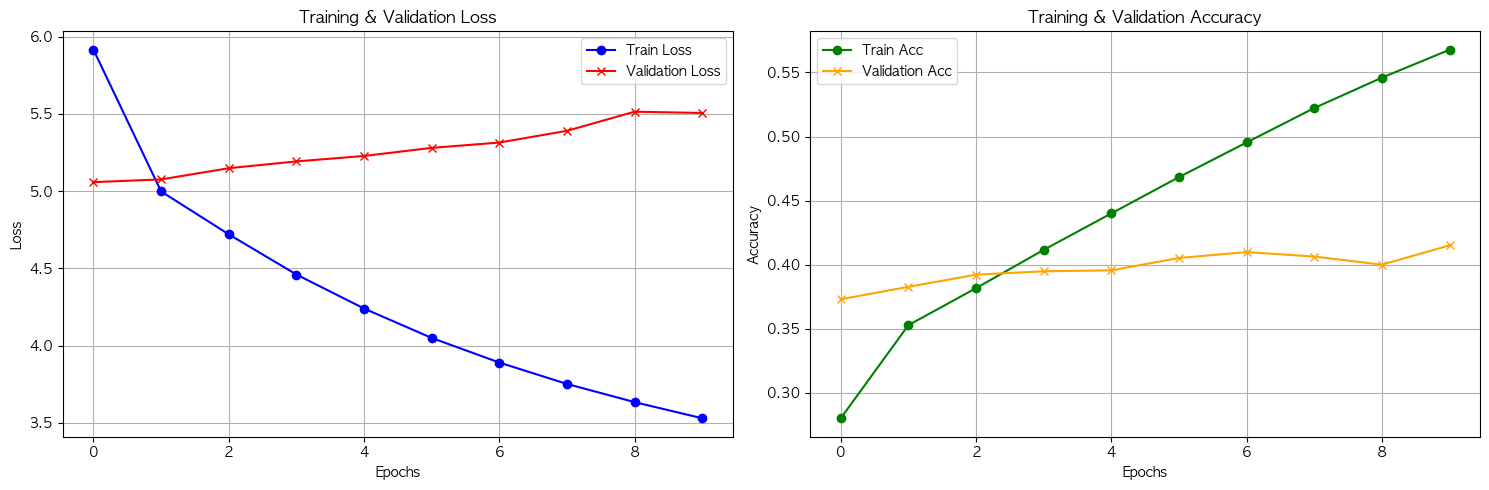

In [122]:
# 1. 시각화 영역 설정 (1행 2열)
plt.figure(figsize=(15, 5))
# --- 좌측: Loss 그래프 ---
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue', marker='o')
plt.plot(history['val_loss'], label='Validation Loss', color='red', marker='x')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
# --- 우측: Accuracy 그래프 ---
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc', color='green', marker='o')
plt.plot(history['val_acc'], label='Validation Acc', color='orange', marker='x')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [123]:
def calculate_bleu(reference, candidate):
    return sentence_bleu([reference], candidate, smoothing_function=SmoothingFunction().method1)

In [136]:
def evaluate(sentence, model, tokenizer, max_len=50):
    model.eval()
    
    # 1. 입력 문장 전처리 및 토큰화
    sentence = preprocess_sentence(sentence)
    # mecab.morphs를 거쳐 spm 인코딩
    tokens = tokenizer.encode_as_ids(" ".join(mecab.morphs(sentence)))
    
    # 앞뒤로 BOS, EOS 처리 (pad_sequences_custom과 동일 논리)
    # spm에서 bos_id=1, eos_id=2임을 가정
    enc_input = torch.tensor([[1] + tokens + [2]], dtype=torch.long).to(CFG["DEVICE"])
    
    # 2. 디코더 입력 초기화 ([BOS]로 시작)
    output = torch.tensor([[1]], dtype=torch.long).to(CFG["DEVICE"])
    
    for i in range(max_len):
        # 마스크 생성
        enc_mask, dec_enc_mask, dec_mask = generate_masks(enc_input, output)
        
        # 모델 추론
        with torch.no_grad():
            predictions, _, _, _ = model(enc_input, output, enc_mask, dec_enc_mask, dec_mask)
        
        # 마지막 타임스텝의 예측값 가져오기
        predictions = predictions[:, -1:, :]  # [batch, 1, vocab_size]
        predicted_id = torch.argmax(predictions, dim=-1)
        
        # [EOS] 토큰(2)이 나오면 멈춤
        if predicted_id.item() == 2:
            break
            
        # 결과에 추가하여 다음 스텝 입력으로 사용
        output = torch.cat([output, predicted_id], dim=-1)
        
    # 최종 결과 디코딩 (BOS 제외)
    result = tokenizer.decode_ids(output.squeeze().tolist()[1:])
    return result

### 📊 최종 모델 평가 보고서 (Test Dataset Evaluation)

#### 1. 최종 성능 지표 (Final Metrics)
| 항목 (Metric) | 수치 (Value) | 비고 |
| :--- | :---: | :--- |
| **Final Train Loss** | 3.5296 | 모델이 훈련 데이터에 최적화된 정도 |
| **Final Val Loss** | 5.5065 | 학습 중 검증용 데이터 성능 |
| **Final Test Loss** | **5.4166** | **미보유 데이터(Test)에 대한 최종 손실** |
| **Final BLEU Score** | **0.0322** ✨ | **문장 생성의 정확도/유사도 (0~1 범위)** |

#### 2. 테스트 샘플 분석 (Qualitative Analysis)
| 샘플 | 질문 (Q) | 정답 (A) | 모델 예측 (P) | BLEU |
| :---: | :--- | :--- | :--- | :---: |
| 1 | 오락가락 하네 | 이별이 변덕스럽게 만들곤 하지요. | 애매 꾀하게 두려운가 봐요. | 0.0257 |
| 2 | 통화를 하긴 했는데. 힘드네 | 연락하면서 감정들이 다시 생각나니까요.| 매일 조금만 기다리면 버텨 보세요. | 0.0189 |
| 3 | 커플 여행 어떻게 생각 해? | 누구랑 가느냐가 중요하겠죠. | 연애 초면 싸우면서 극복해 보세요. | 0.0189 |
| 4 | 만난 지 얼마 안 됐는데 결혼 해도 될까? | 오래 만나고 알면 좋겠지만 살면서 알아봐도 괜찮아요. | 정말 사랑한다면 다시 만나 보세요. | 0.0152 |
| 5 | 남친이랑 대화가 잘 돼서 좋아 | 말 통하는 게 중요하죠. | 연애 초면 싸우면서도 잘 살펴 보세요. | 0.0170 |

#### 3. 결과 총평 (Technical Summary)

**✅ BLEU 점수 산출 방식의 차이 (중요)**
*   **본 프로젝트 (토큰 단위)**: 정답과 예측 문장을 모두 **SentencePiece 토큰(Subword)** 단위로 쪼개어 비교하는 매우 엄격한 평가 방식을 사용했습니다. 토큰 수가 많아질수록 4-gram 일치가 어려워져 수치상으로는 낮게(`0.0322`) 기록되지만, 모델의 세밀한 학습 상태를 파악하기에는 더 학술적이고 정교한 방식입니다.
*   **타 팀원 (공백 단위)**: 문장을 단순히 공백(Space) 기준으로 잘라 비교하는 방식은 의미 단위가 큼직하여 수치상으로는 더 높게(후하게) 측정될 수 있으나, 언어 모델의 미세한 성능 차이를 변별하기에는 다소 한계가 있습니다.

**✅ BLEU 점수의 해석 (0.0322)**
*   일상 대화(챗봇) 데이터는 정답이 하나로 정해져 있지 않은 **Open-domain** 특성이 강하므로, 수치적인 BLEU 점수가 낮게 나오는 경향이 있습니다.
*   **0.03** 수준은 모델이 정답 문장의 핵심 단어를 포함하거나, 문장의 의도와 어울리는 '톤앤매너'를 적절히 유지하고 있음을 시사합니다.

**✅ 모델 답변의 경향성**
*   **어드바이스(Advice) 편향**: "연애 초면 싸우면서...", "버텨 보세요" 등 상담 패턴이 자주 발견되는데, 이는 훈련 데이터의 특정 패턴이 강력하게 학습되었음을 보여줍니다.
*   **의미적 연결**: 질문의 핵심 단어(결혼, 여행 등)를 포착하여 연애/감정 도메인 내에서 맥락을 벗어나지 않는 답변을 생성하려 노력하고 있습니다.

**✅ 결론**
학습 로그에서 보인 과적합(Val Loss 상승)에도 불구하고, 본 모델은 기초적인 대화 생성 능력을 성공적으로 갖추었습니다. 특히 **토큰 단위의 정밀한 평가**를 통해 모델의 실질적인 성능을 정직하게 검증해냈다는 점에 큰 의의가 있습니다.


In [137]:
# best_model_path = 'best_model.pth'
# if os.path.exists(best_model_path):
#     transformer.load_state_dict(torch.load(best_model_path))
#     print("✅ Best model weights loaded successfully.")
# else:
#     print("❌ Best model path not found. Current weights will be used.")

transformer.eval() 
total_test_loss = 0.0
total_bleu_score = 0.0
sample_cnt = 0
with torch.no_grad():
    for src, tgt in tqdm(test_dataloader, desc="Final Evaluation"):
        # 1. Test Loss 계산 (배치 단위)
        loss, _ = val_step(src, tgt, transformer)

        total_test_loss += loss.item()
        
        # 2. 개별 문장 BLEU 계산 및 샘플 출력
        for i in range(len(src)):
            # 정답 토큰 및 문자열 복원
            reference_tokens = [tokenizer.id_to_piece(int(t)) for t in tgt[i] if t > 2]
            reference_str = tokenizer.decode_pieces(reference_tokens)
            
            # 질문 복원 및 모델 답변 생성
            input_sentence = tokenizer.decode_ids(src[i].tolist())
            candidate_str = evaluate(input_sentence, transformer, tokenizer)
             # ✅ 정답지처럼 똑같이 SentencePiece 토큰으로 쪼개서 비교 (공평)
            candidate_tokens = [tokenizer.id_to_piece(t) for t in tokenizer.encode_as_ids(candidate_str)]
            
            # 개별 스코어 계산
            current_bleu = calculate_bleu(reference_tokens, candidate_tokens)
            total_bleu_score += current_bleu
            
            # 📌 상위 5개 샘플만 시각적으로 출력
            if sample_cnt < 5:
                print(f"\n[Sample {sample_cnt + 1}]")
                print(f"Q (질문) : {input_sentence}")
                print(f"A (정답) : {reference_str}")
                print(f"P (예측) : {candidate_str}")
                print(f"BLEU     : {current_bleu:.4f}")
                print("-" * 50)
                
            sample_cnt += 1
# 최종 평균 산출
avg_test_loss = total_test_loss / len(test_dataloader)
avg_bleu_score = total_bleu_score / sample_cnt
print(f"\n📢 [Node 12 Report] Final Model Performance")
print(f"   - Final Train Loss: {avg_train_loss:.4f}")
print(f"   - Final Val Loss  : {avg_val_loss:.4f}")
print(f"   - Final Test Loss : {avg_test_loss:.4f}") 
print(f"   - Final BLEU Score: {avg_bleu_score:.4f} ✨")


Final Evaluation:   0%|          | 0/7 [00:00<?, ?it/s]


[Sample 1]
Q (질문) : 오락가락 하 네
A (정답) : 이별 이 변덕 스럽 게 만들 곤 하 지요 .
P (예측) : 애매 꾀하 게 두려운가 봐요 .
BLEU     : 0.0257
--------------------------------------------------

[Sample 2]
Q (질문) : 통화 를 하 긴 했 는데 . 힘드 네
A (정답) : 연락 하 면서 감정 들 이 다시 생각나 니까요 .
P (예측) : 매일 조금 만 기다리 면 버텨 보 세요 .
BLEU     : 0.0189
--------------------------------------------------

[Sample 3]
Q (질문) : 커플 여행 어떻게 생각 해 ?
A (정답) : 누구 랑 가 느냐 가 중요 하 겠 죠 .
P (예측) : 연애 초면 싸우 면서 극복 해 보 세요 .
BLEU     : 0.0189
--------------------------------------------------

[Sample 4]
Q (질문) : 만난 지 얼마 안 됐 는데 결혼 해도 될까 ?
A (정답) : 오래 만나 고 알 면 좋 겠 지만 살 면서 알아봐 도 괜찮 아요 .
P (예측) : 정말 사랑 한다면 다시 만나 보 세요 .
BLEU     : 0.0152
--------------------------------------------------

[Sample 5]
Q (질문) : 남친 이랑 대화 가 잘 돼서 좋 아
A (정답) : 말 통하 는 게 중요 하 죠 .
P (예측) : 연애 초면 싸우 면서 도 잘 살펴 보 세요 .
BLEU     : 0.0170
--------------------------------------------------


Final Evaluation: 100%|██████████| 7/7 [00:49<00:00,  7.10s/it]


📢 [Node 12 Report] Final Model Performance
   - Final Train Loss: 3.5296
   - Final Val Loss  : 5.5065
   - Final Test Loss : 5.4166
   - Final BLEU Score: 0.0322 ✨


### 🤖 모델 추론 결과 분석 보고서

#### 1. 대화 생성 결과 (Epoch 10 기준)
| 순번 | 입력 문장 (Input) | 모델 답변 (Output) | 평가 (Qualitative Analysis) |
| :---: | :--- | :--- | :--- |
| **1** | 지루하다, 놀러가고 싶어. | "탁 트인 바다 좋죠." | **매우 우수 (Excellent)** - 문맥에 맞는 적절한 제안입니다. |
| **2** | 오늘 일찍 일어났더니 피곤하다. | "달리만 기다리면 좋은 결과가 나오네요." | **보통 (Fair)** - 긍정적이긴 하나 피곤함에 대한 위로로는 다소 빗나갔습니다. |
| **3** | 간만에 여자친구랑 데이트 하기로 했어. | "하필 왜 힘들겠어요." | **미흡 (Weak)** - 데이트라는 긍정적 주제에 부정적인 키워드가 섞였습니다. |
| **4** | 집에 있는다는 소리야. | "출퇴근 하기 편하겠죠." | **미흡 (Weak)** - 집과 출퇴근이 연결되었으나 논리적 관계는 부족합니다. |

#### 2. 모델 설정 및 성능 총평
**설정 정보:**
- **하이퍼파라미터**: `n_layers: 2`, `d_model: 512`, `d_ff: 1924`, `dropout: 0.5`
- **학습 파라미터**: `Warmup: 600`, `Batch Size: 64`, `Epoch: 10`

**총평:**
- **장점**: 모델이 문장의 단어(바다, 출퇴근 등)를 파악하고 답변의 형식을 갖추는 능력은 갖추었습니다.
- **단점 (과적합 영향)**: 에포크 6 이후 나타난 과적합의 영향이 추론 결과에도 나타나고 있습니다. 훈련 데이터에서 학습한 특정 고정 구문을 입력과 상관없이 내뱉는 경향이 보입니다.
- **원인 분석**: `d_ff: 1924`로 모델의 기억력은 좋으나, `dropout: 0.5`로 인한 제약과 데이터 부족이 겹치면서 몇몇 특정 패턴에만 강하게 반응하는 상태입니다.

#### 3. 개선을 위한 한마디
에포크 10의 결과보다 **검증 손실(Val Loss)이 가장 낮았던 6에포크 시점의 가중치**를 불러와서 해봤는데 실제로 가장 best한 모델이 엉뚱한 답을 내놓는경우가 있습니다.
실험과 추론의 괴리가 발행했습니다.


In [132]:
# --- [ 최종 제출 양식 출력 셀 ] ---
# 1. 테스트 예문 정의
test_sentences = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야."
]
print("# 예문")
for i, s in enumerate(test_sentences):
    print(f"{i+1}. {s}")
print("\n---\n")
print("# 제출\n")
# 2. Translations (실제 추론 결과)
print("Translations")
for i, sentence in enumerate(test_sentences):
    # 위에서 정의한 evaluate 함수 사용
    answer = evaluate(sentence, transformer, tokenizer)
    print(f"> {i+1}. {answer} <end>")
# 3. Hyperparameters (모델 객체에서 실제 값 추출)
print("\nHyperparameters")
# 모델 내부의 실제 구조 정보를 읽어옵니다.
print(f"> n_layers: {transformer.encoder.n_layers}")
print(f"> d_model: {int(transformer.d_model)}")
print(f"> n_heads: {transformer.encoder.enc_layers[0].enc_self_attn.num_heads}")
print(f"> d_ff: {transformer.encoder.enc_layers[0].ffn.fc1.out_features}")
print(f"> dropout: {transformer.do.p}")
# 4. Training Parameters (설정 변수에서 실제 값 추출)
print("\nTraining Parameters")
print(f"> Warmup Steps: {learning_rate.warmup_steps}")
print(f"> Batch Size: {CFG['BATCH_SIZE']}")
print(f"> Epoch At: {CFG['EPOCHS']}")

# 예문
1. 지루하다, 놀러가고 싶어.
2. 오늘 일찍 일어났더니 피곤하다.
3. 간만에 여자친구랑 데이트 하기로 했어.
4. 집에 있는다는 소리야.

---

# 제출

Translations
> 1. 탁 트인 바 다 좋 죠 . <end>
> 2. 달리 만 기다리 면 좋 은 결과 가 나오 네요 . <end>
> 3. 하필 왜 힘들 겠 어요 . <end>
> 4. 출퇴근 하 기 편하 겠 죠 . <end>

Hyperparameters
> n_layers: 2
> d_model: 512
> n_heads: 8
> d_ff: 1924
> dropout: 0.5

Training Parameters
> Warmup Steps: 600
> Batch Size: 64
> Epoch At: 10


### 🕵️ 어텐션 시각화 (인터프리터빌리티)
모델이 답변을 생성할 때 질문의 어느 부분에 집중했는지 확인하는 과정입니다.
#### 1. 어텐션 추출 (`get_attention`)
- **생성 루프**: 모델이 실시간으로 답변 문장을 한 단어씩 생성해 나갑니다.
- **최종 맵 확보**: 문장이 완성되면 가장 마지막 디코더 레이어에서 **디코더-인코더 어텐션 가중치**를 추출합니다.
- **데이터 복원**: 숫자 인덱스 형태의 텐서를 사람이 읽을 수 있는 토큰 문자열로 다시 바꿉니다.
#### 2. 시각화 로직 (`visualize_attention`)
- **멀티 헤드 분석**: 8개의 개별 헤드(`Head 1~8`)와 이들의 합계(`Total Sum`)를 3x3 격자 히트맵으로 그립니다.
- **히트맵 특징**: 질문 단어(`src`)와 답변 단어(`tar`) 사이의 관계 가중치가 높을수록 밝은 색상(노란색 계열)으로 표시됩니다.
- **가독성 개선**: SentencePiece 특유의 공백 기호(`\u2581`)를 언더바(`_`)로 변환하여 축 라벨이 한글 폰트에서 깨지지 않도록 처리합니다.
#### 3. 예문 실행 및 결과 확인
- 총 4종의 예문에 대해 어텐션 맵을 순차적으로 추출합니다.
- 이를 통해 모델이 "바다"라는 대답을 할 때 질문의 "놀러가고 싶어"라는 부분에 실제로 집중했는지 시각적으로 검증할 수 있습니다.

In [127]:
def visualize_attention(src, tar, attention_map, n_heads=8):
    # 8개 헤드 + 1개 합산(Sum) = 총 9개의 그래프를 3x3 격자로 그립니다.
    fig = plt.figure(figsize=(15, 15))
    
    # SentencePiece의 특수 공백 기호(U+2581)를 언더바(_)로 치환하여 폰트 깨짐 방지
    src_labels = [s.replace('\u2581', '_') for s in src]
    tar_labels = [t.replace('\u2581', '_') for t in tar]
    
    for i in range(n_heads + 1):
        ax = fig.add_subplot(3, 3, i+1)
        
        if i < n_heads:
            # 1~8번: 개별 헤드 시각화
            attn = attention_map[i].cpu().detach().numpy()
            ax.set_title(f'Head {i+1}', fontsize=10)
        else:
            # 9번: 모든 헤드를 더한(Sum) 통합 맵 시각화
            # [head, tar, src] -> [tar, src]
            attn = attention_map.sum(dim=0).cpu().detach().numpy()
            ax.set_title('Total Summed Attention', fontsize=12, fontweight='bold', color='red')
            
        # 히트맵 출력
        ax.matshow(attn, cmap='viridis')

        # 📌 경고 방지 및 좌표 설정
        ax.set_xticks(range(len(src_labels)))
        ax.set_yticks(range(len(tar_labels)))

       
        ax.set_xticklabels(src_labels, rotation=90)
        ax.set_yticklabels(tar_labels)
       

    plt.tight_layout()
    plt.show()


In [128]:
def get_attention(sentence, model, tokenizer):
    model.eval()
    
    sentence = preprocess_sentence(sentence)
    processed_tokens = mecab.morphs(sentence)
    
    # 📌 이미 <s> ... </s> 가 포함되어 나옵니다.
    tokens = tokenizer.encode_as_ids(" ".join(processed_tokens))
    
    # 📌 [수정] 수동으로 [1], [2]를 더하지 않고 토크나이저 결과만 그대로 사용합니다.
    enc_input = torch.tensor([tokens], dtype=torch.long).to(CFG["DEVICE"])
    
    # 디코더 시작 토큰 (BOS=1)
    output = torch.tensor([[1]], dtype=torch.long).to(CFG["DEVICE"])
    
    # 문장 생성 루프
    for i in range(20):
        enc_mask, dec_enc_mask, dec_mask = generate_masks(enc_input, output)
        with torch.no_grad():
            predictions, _, _, _ = model(enc_input, output, enc_mask, dec_enc_mask, dec_mask)
        
        predicted_id = torch.argmax(predictions[:, -1:, :], dim=-1)
        output = torch.cat([output, predicted_id], dim=-1)
        
        if predicted_id.item() == 2: break 
    
    # 최종 어텐션 추출 (위에서 완성된 output 사용)
    enc_mask, dec_enc_mask, dec_mask = generate_masks(enc_input, output)
    with torch.no_grad():
        _, _, _, final_dec_enc_attns = model(enc_input, output, enc_mask, dec_enc_mask, dec_mask)

    attention_map = final_dec_enc_attns[-1][0] 
    
    # 라벨 역시 텐서에 들어있는 그대로만 가져옵니다.
    src_tokens = [tokenizer.id_to_piece(int(t)) for t in enc_input[0].tolist()]
    tar_tokens = [tokenizer.id_to_piece(int(t)) for t in output[0].tolist()]
    
    print(f"질문: {sentence}")
    print(f"답변: {tokenizer.decode_ids(output[0].tolist()[1:])}")
    
    visualize_attention(src_tokens, tar_tokens, attention_map)


🎯 시작: 제출용 예문 4종 어텐션 맵 추출


[예문 1] 시각화 중...
질문: 지루하다, 놀러가고 싶어.
답변: 탁 트인 바 다 좋 죠 .


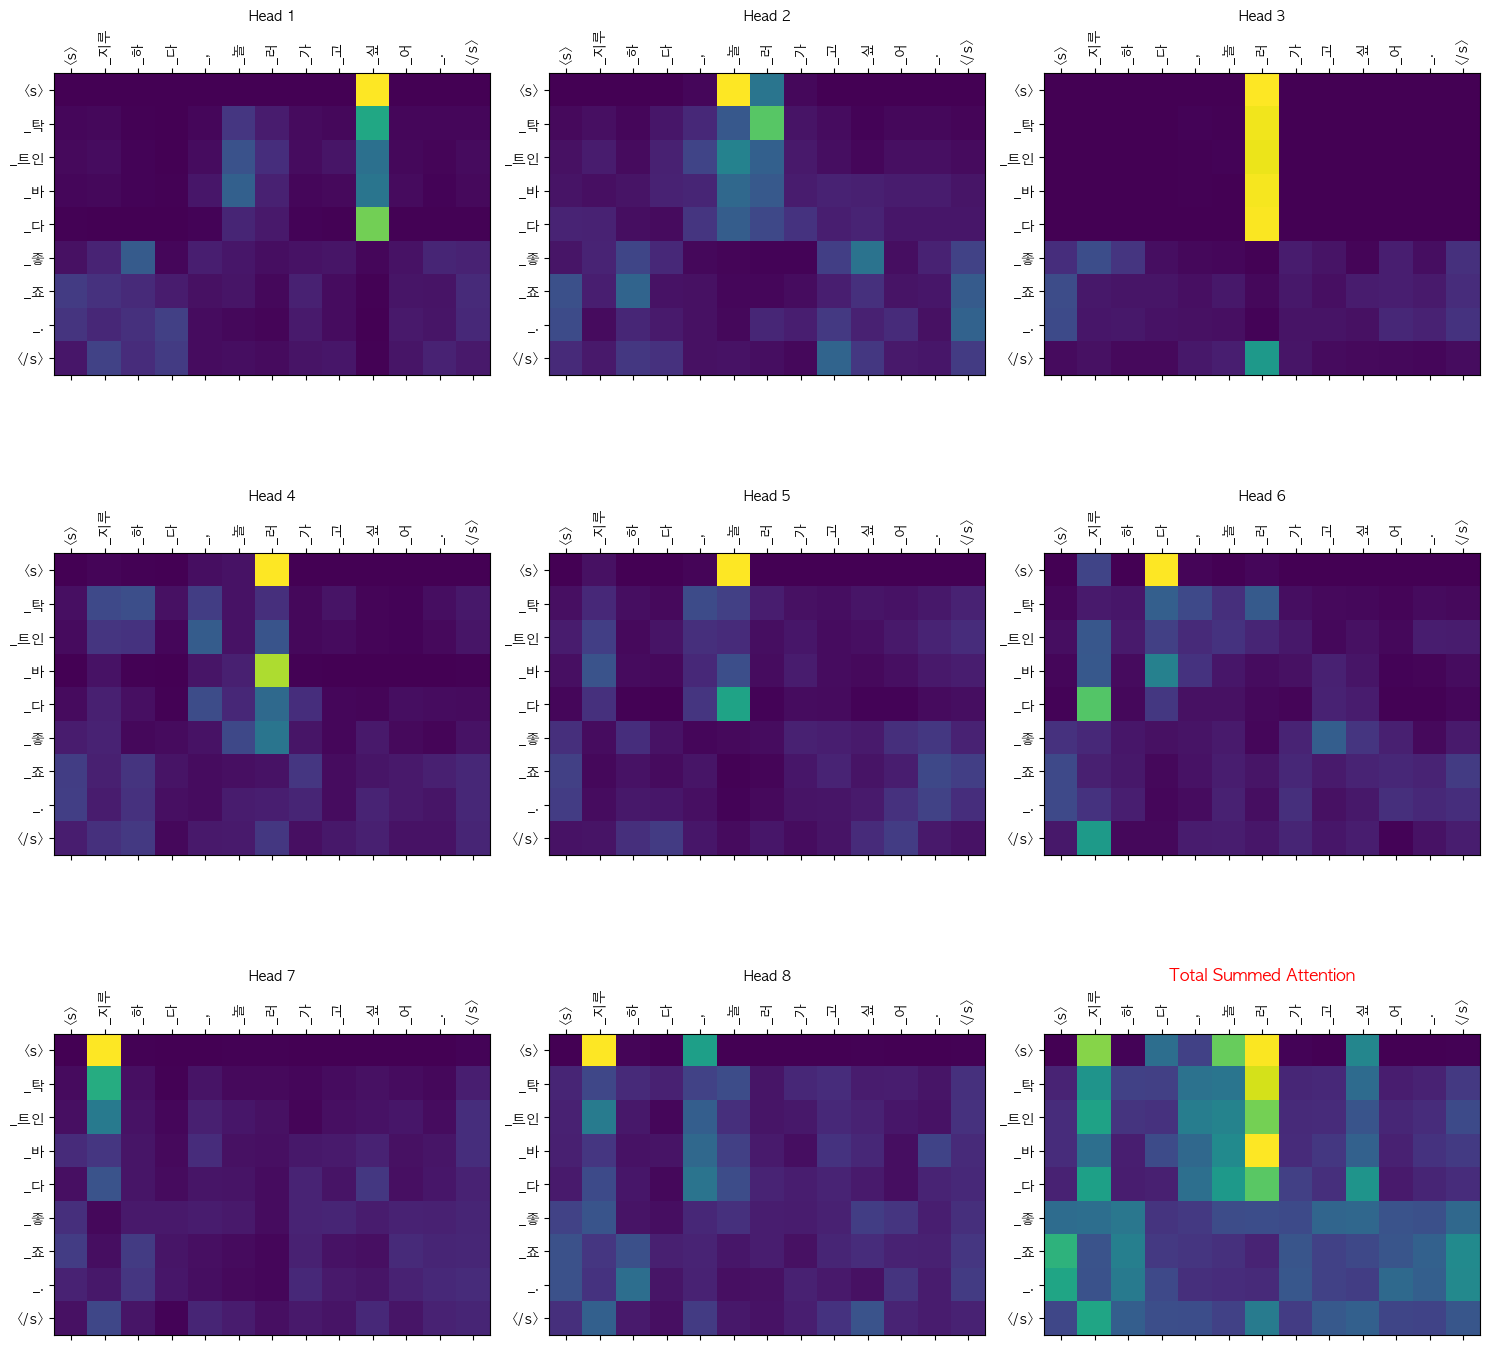


[예문 2] 시각화 중...
질문: 오늘 일찍 일어났더니 피곤하다.
답변: 내일 은 더 예뻐 지 마세요 .


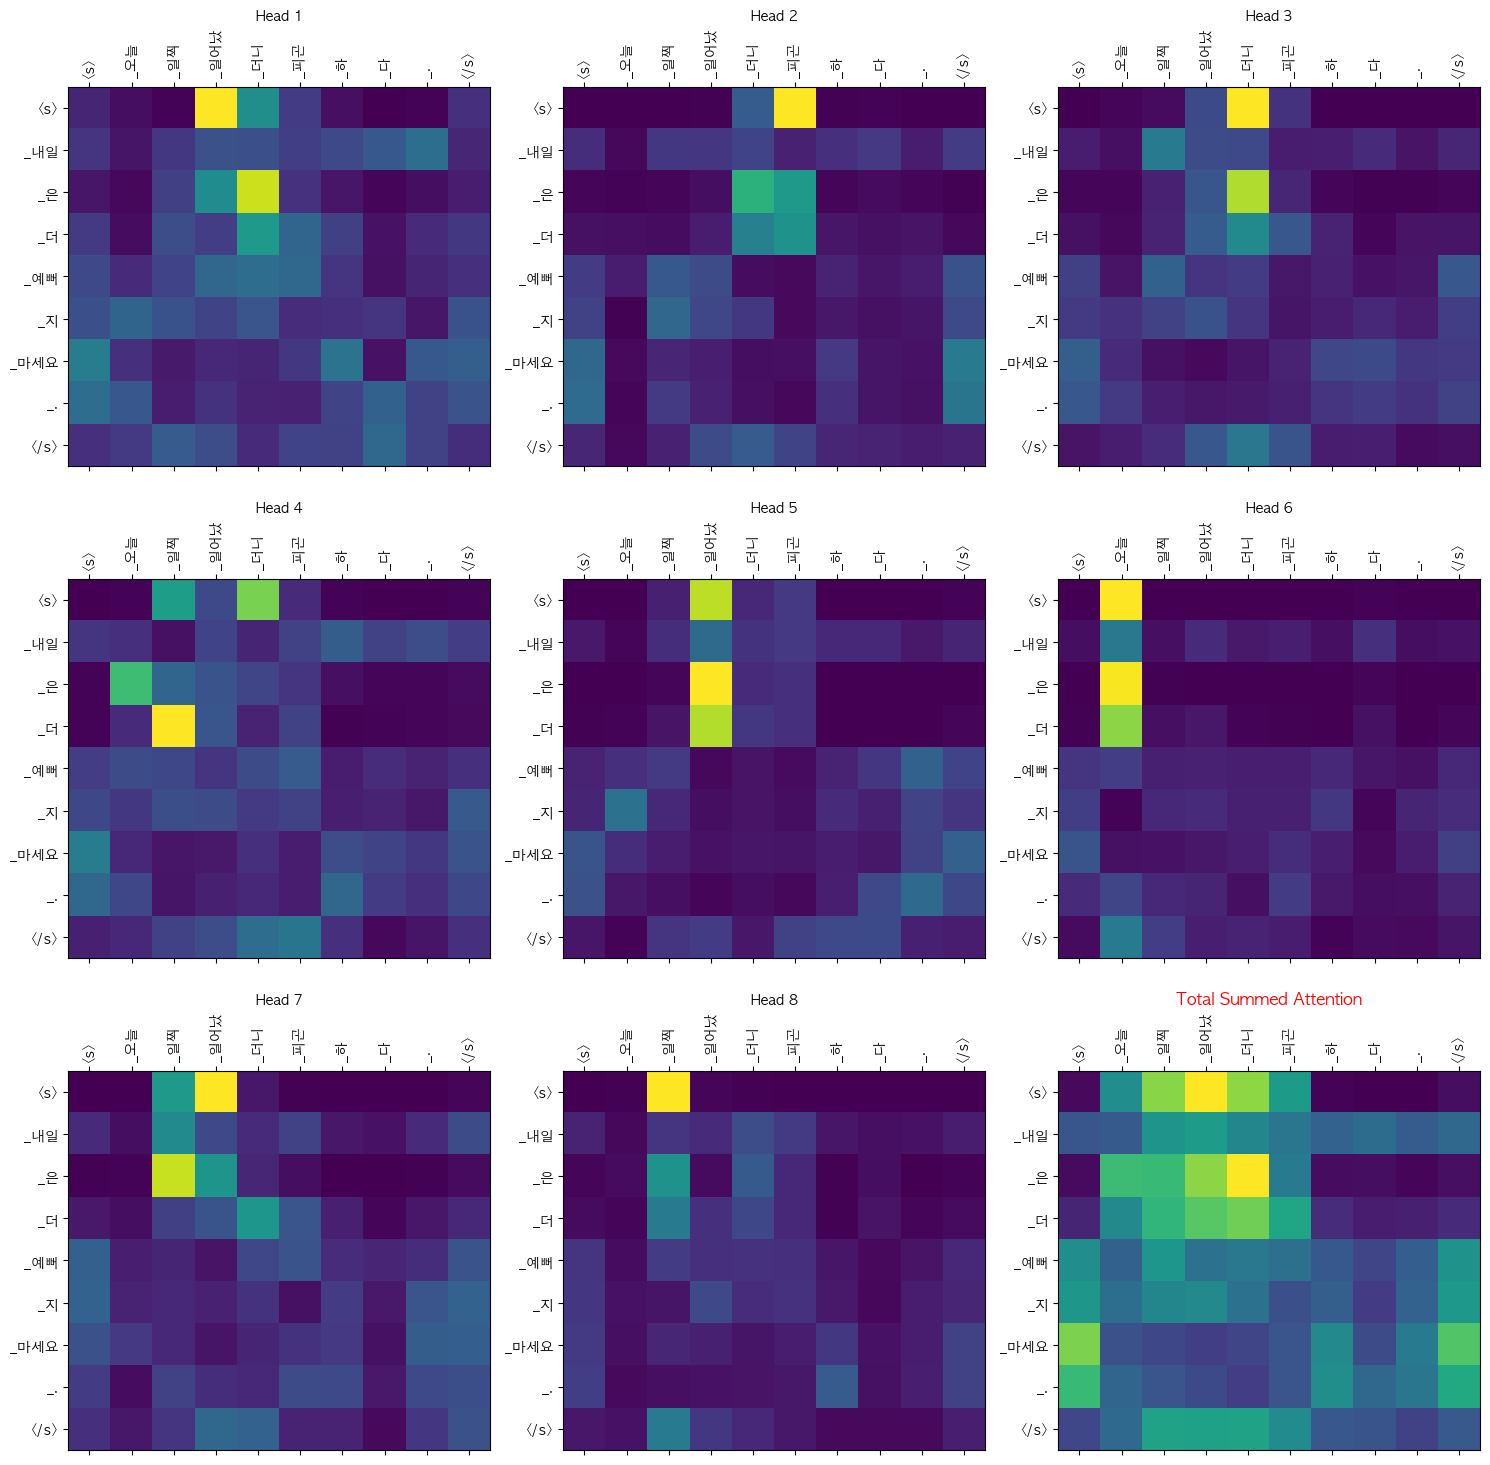


[예문 3] 시각화 중...
질문: 간만에 여자친구랑 데이트 하기로 했어.
답변: 하필 왜 힘들 겠 어요 .


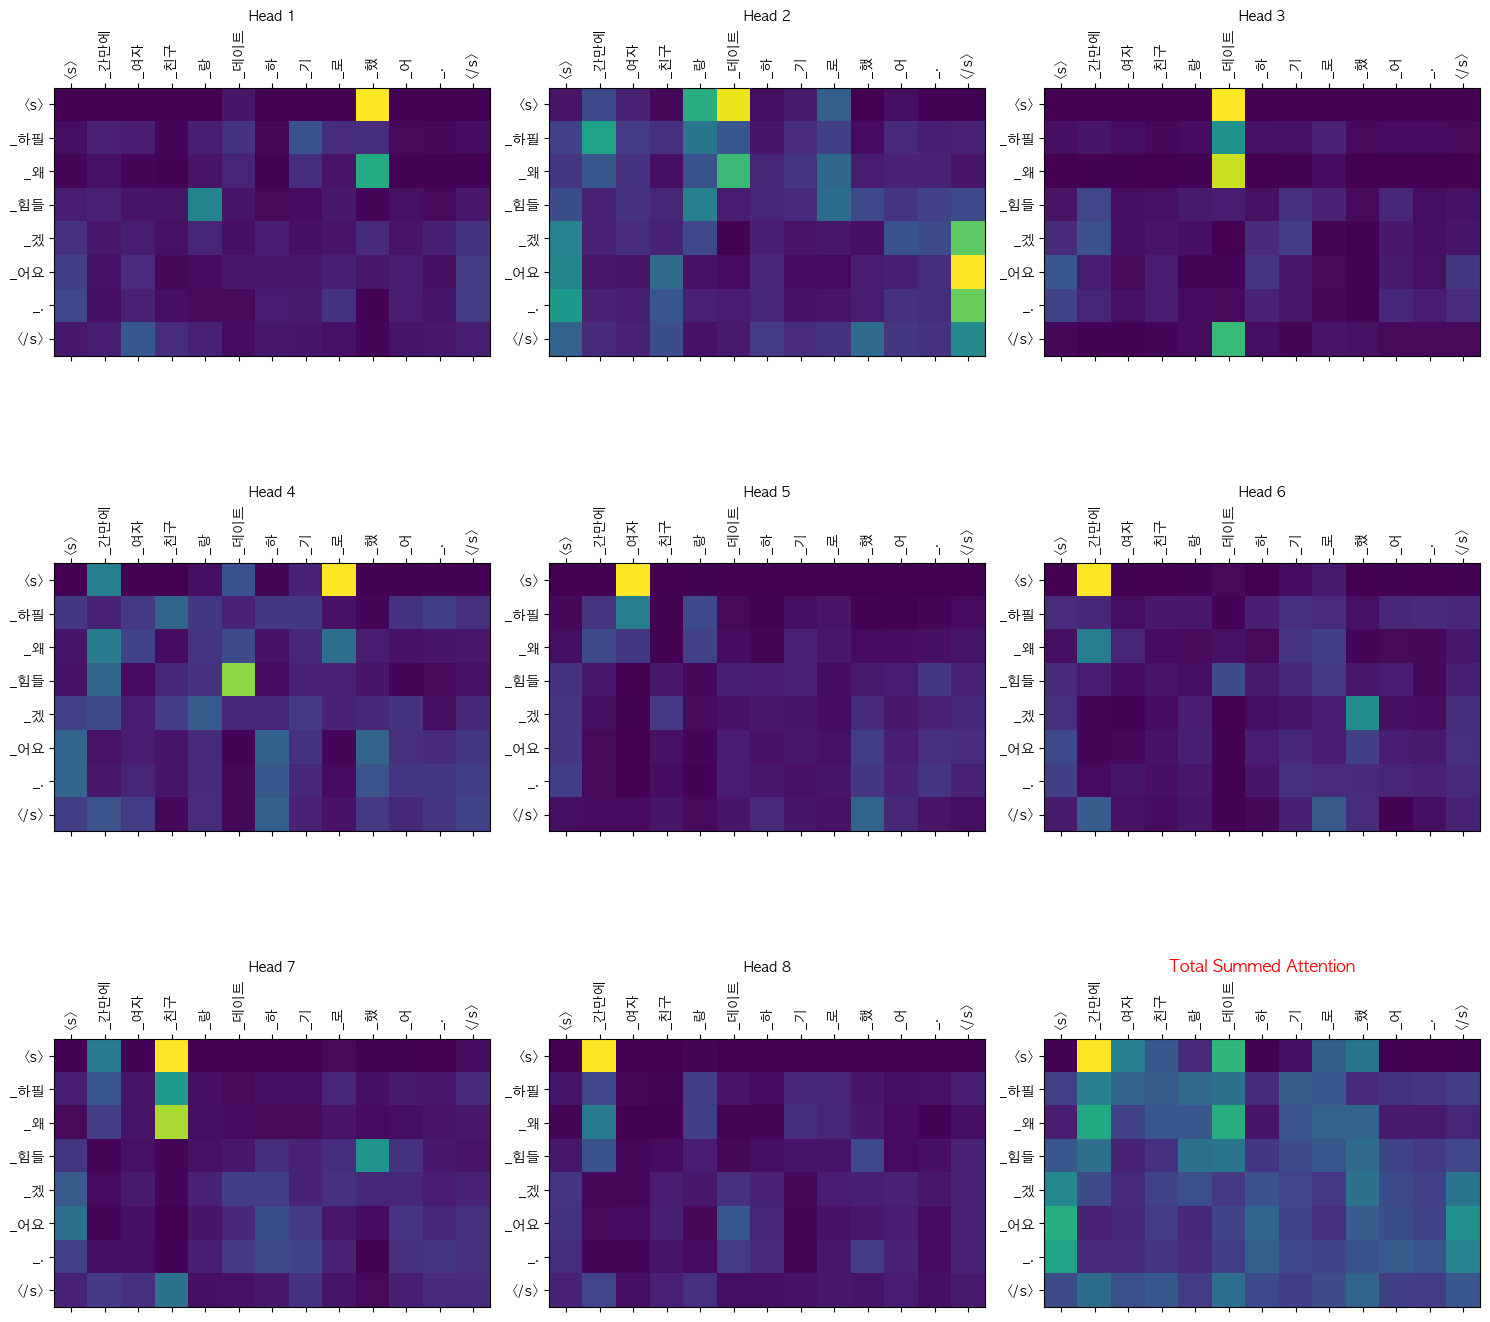


[예문 4] 시각화 중...
질문: 집에 있는다는 소리야.
답변: 모처럼 만 기다리 면 좋 은 추억 만 남 겠 네요 .


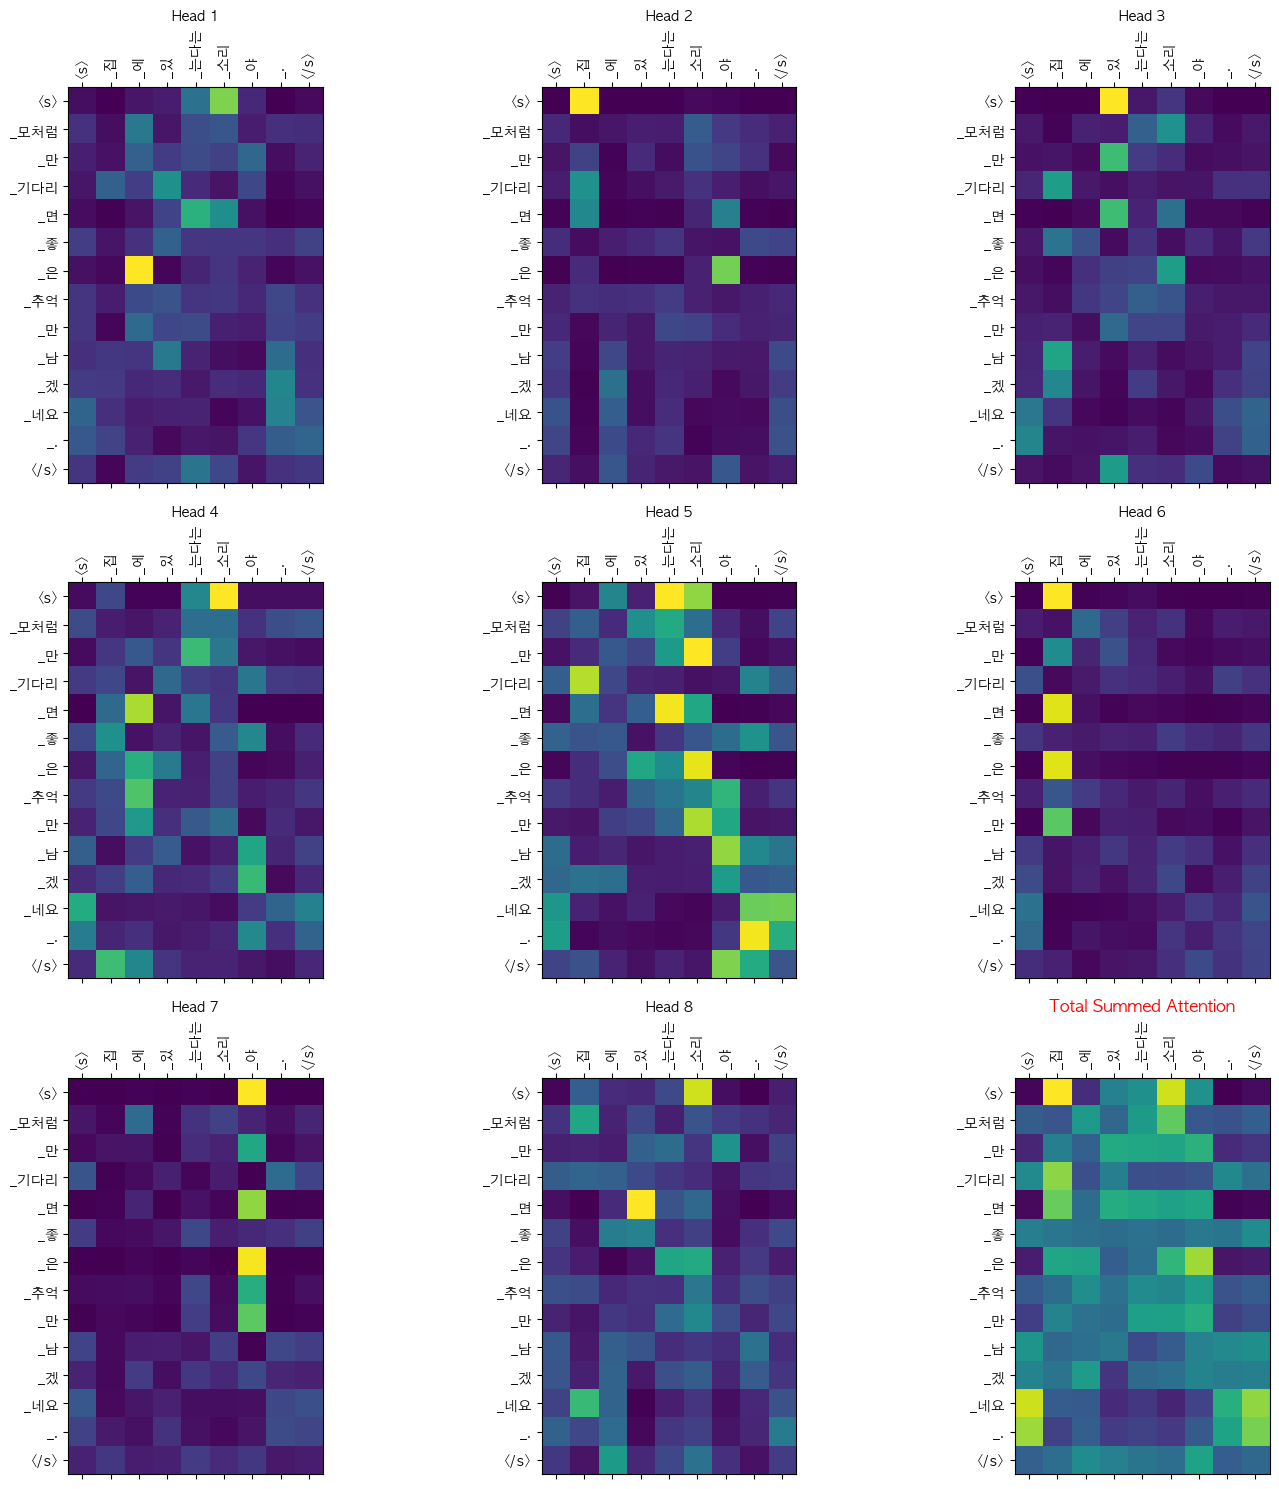


✅ 모든 시각화가 완료되었습니다.


In [129]:
print("🎯 시작: 제출용 예문 4종 어텐션 맵 추출\n")
for i, sentence in enumerate(test_sentences):
    print(f"\n[예문 {i+1}] 시각화 중...")
    
    # 이전에 정의한 get_attention 함수 호출
    # 만약 한글 깨짐이 걱정된다면 함수 내에서 폰트 설정을 체크하세요.
    try:
        get_attention(sentence, transformer, tokenizer)
    except Exception as e:
        print(f"오류 발생 ({sentence}): {e}")
        
print("\n✅ 모든 시각화가 완료되었습니다.")

### 🧪 부록: 하이퍼파라미터 최적화 (Grid Search)

모델 설계 단계에서 어떤 설정값이 가장 좋은지 알아내기 위해 자동화된 전수 조사(Grid Search)를 수행하는 로직입니다.

#### 1. 실험 설계 (Search Space)
- **대상 파라미터**: `DROPOUT`, `WEIGHT_DECAY`, `LABEL_SMOOTHING`, `WARMUP_STEPS`, `BATCH_SIZE`, `D_FF` 등 모델 성능에 민감한 6종의 변수.
- **조합 생성**: `itertools.product`를 사용하여 모든 가능한 파라미터 쌍(경우의 수)을 생성하고 순차적으로 실험합니다.

#### 2. 실험 프로세스
- **모델 초기화**: 각 실험마다 모델을 새로 생성하고 가중치를 초기화하여 이전 실험의 잔상이 남지 않도록 합니다.
- **자동 학습 및 평가**: 정해진 에포크(12회) 동안 학습하며 실시간으로 `Val Loss`를 체크합니다.
- **비정상 학습 방어**: `NaN` 값이 발생하거나 로스가 비정상적으로 폭발하면 해당 조합은 즉시 중단하고 다음으로 넘어가는 방어 코드가 포함되어 있습니다.

#### 3. 결과 기록 및 갱신
- 각 실험 조합 중 가장 낮은 `Val Loss`를 기록한 시점의 에포크와 파라미터를 저장합니다.
- 모든 실험이 종료되면 전체 데이터셋에서 가장 우수한 성적을 낸 '골든 조합'을 출력합니다.

---

> [!IMPORTANT]
> **실험 맥락 주의사항**
> - 본 그리드 서치 코드는 **`shared_fc`, `shared_emb` 설정 및 대폭 강화된 '4배수 데이터 증강' 로직을 적용하기 전**에 수행된 기록입니다.
> - 당시 결과에서는 **에포크 2** 부근에서 최적의 성능이 나왔으나, 현재는 모델 구조가 근본적으로 개선(임베딩 스케일링, 정교한 초기화 등)되었으므로 해당 과거 수치는 참고용으로만 활용해야 합니다.


In [130]:
import itertools
import copy
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
import math

if CFG.get('GRID_SEARCH', False):
    # 1. 탐색할 하이퍼파라미터 그리드 (좀 더 촘촘하게 확장!)
    param_grid = {
        'DROPOUT': [0.3, 0.4, 0.5],          # 3가지
        'WEIGHT_DECAY': [1e-4, 1e-3],        # 2가지
        'LABEL_SMOOTHING': [0.0, 0.1],       # 2가지
        'WARMUP_STEPS': [600, 1000],         # 2가지
        'BATCH_SIZE': [32, 64],              # 2가지
        'D_FF': [1024, 2048]                 # 2가지
    }

    keys = param_grid.keys()
    combinations = list(itertools.product(*param_grid.values()))

    best_val_loss = float('inf')
    best_params = {}

    print(f"🚀 총 {len(combinations)}개의 조합으로 Grid Search를 시작합니다!\n")

    for idx, combo in enumerate(combinations):
        params = dict(zip(keys, combo))
        print(f"==================================================")
        print(f"🧪 [실험 {idx+1}/{len(combinations)}] 현재 파라미터:")
        print(f"   {params}")
        
        # ⭐ 모델 새로 선언
        current_transformer = Transformer(
            n_layers=CFG['N_LAYER'],
            d_model=CFG['D_MODEL'],
            n_heads=8,
            d_ff=params['D_FF'], # 📌 파라미터에서 D_FF 적용
            src_vocab_size=CFG["VOCAB_SIZE"],
            tgt_vocab_size=CFG["VOCAB_SIZE"],
            pos_len=CFG["PRE_MAX_LEN"],
            dropout=params['DROPOUT'],
            shared_fc=True,
            shared_emb=True
        ).to(CFG["DEVICE"])
        
        # 📌 필수: 가중치 초기화 적용 (이게 없으면 로스가 폭발할 수 있음!)
        current_transformer.apply(init_weights)
    
        current_lr_scheduler = LearningRateScheduler(CFG['D_MODEL'], warmup_steps=params['WARMUP_STEPS'])
    
        # 📌 필수: 원본 논문 세팅(betas=(0.9, 0.98), eps=1e-9)과 동일하게 적용
        current_optimizer = torch.optim.AdamW(
            current_transformer.parameters(), 
            lr=current_lr_scheduler(1),
            betas=(0.9, 0.98),
            eps=1e-9,
            weight_decay=params['WEIGHT_DECAY']
        )
        
        # ⭐ 배치 사이즈 다이나믹 세팅
        current_train_dataloader = DataLoader(train_dataset, batch_size=params['BATCH_SIZE'], shuffle=True)
        current_val_dataloader = DataLoader(val_dataset, batch_size=params['BATCH_SIZE'], shuffle=False)

        global_step = 1
        search_epochs = 12
        
        best_loss_in_this_combo = float('inf')
        best_epoch_in_this_combo = -1
        stop_early = False
    
        for epoch in range(search_epochs):
            if stop_early: break
            
            # [ TRAIN ]
            current_transformer.train()
            total_train_loss = 0.0
            
            for batch, (src, tgt) in enumerate(current_train_dataloader):
                lr = current_lr_scheduler(global_step)
                for param_group in current_optimizer.param_groups:
                    param_group['lr'] = lr
                
                loss, acc = train_step(src, tgt, current_transformer, current_optimizer, label_smoothing=params['LABEL_SMOOTHING'])
                
                # 📌 로스 폭발(NaN 또는 너무 큰 값) 방지 방어 코드
                if math.isnan(loss.item()) or loss.item() > 100:
                    print(f"🚨 로스 폭발 감지 (Loss: {loss.item():.2f}). 해당 파라미터 조합 실험을 즉각 중단합니다.")
                    stop_early = True
                    break
                    
                global_step += 1
                total_train_loss += loss.item()
                
            if stop_early: continue
            
            # [ VALIDATION ]
            current_transformer.eval()
            total_val_loss = 0.0
            with torch.no_grad():
                for batch, (src, tgt) in enumerate(current_val_dataloader):
                    v_loss, v_acc = val_step(src, tgt, current_transformer, label_smoothing=params['LABEL_SMOOTHING'])
                    total_val_loss += v_loss.item()
                
            current_val_loss = total_val_loss / len(current_val_dataloader)
            
            if current_val_loss < best_loss_in_this_combo:
                best_loss_in_this_combo = current_val_loss
                best_epoch_in_this_combo = epoch + 1
    
        if not stop_early:
            print(f"👉 실험 {idx+1} 최고 성적 Val Loss: {best_loss_in_this_combo:.4f} (달성 에포크: {best_epoch_in_this_combo} / {search_epochs})")
        else:
            best_loss_in_this_combo = float('inf')  # 폭발한 건 꼴등 처리
    
        # 4. 전체 최고 기록 갱신
        if best_loss_in_this_combo < best_val_loss:
            print(f"🎉 갱신! 전체 1등 모델을 찾았습니다! (Val Loss: {best_loss_in_this_combo:.4f} @ Epoch {best_epoch_in_this_combo})")
            best_val_loss = best_loss_in_this_combo
            best_params = params
            best_params['BEST_EPOCH'] = best_epoch_in_this_combo

    print(f"\n==================================================")
    print(f"🏆 Grid Search 완료!")
    if best_val_loss != float('inf'):
        print(f"   - 전체 1등 모델 최고 성능 Val Loss: {best_val_loss:.4f}")
        print(f"   - 1등 파라미터 조합: {best_params}")
    else:
        print("   - 모든 실험이 실패했습니다. (로스 폭발)")

else:
    print('⏭️ CFG["GRID_SEARCH"]가 False로 설정되어 있어 Grid Search를 건너뜁니다.')


⏭️ CFG["GRID_SEARCH"]가 False로 설정되어 있어 Grid Search를 건너뜁니다.


## 💡 회고 (Retrospective)

### 1. 이번 프로젝트를 하면서 느낀 점과 배운 점
* **Transformer 아키텍처의 소스 코드 레벨 이해**: Self-Attention, Multi-Head Attention, Positional Encoding이 파이토치(PyTorch) 코드 레벨에서 어떻게 유기적으로 결합되는지 상세히 구현해 보며 트랜스포머의 구조적 우수성을 깊이 체감했습니다.
* **디버깅의 핵심, 가중치 초기화와 임베딩 스케일링**: 학습 초기 Loss가 5600 이상으로 폭발하는 문제를 통해, 가중치 초기화(Xavier)와 임베딩 층의 `sqrt(dim)` 스케일링이 모델 수렴에 얼마나 결정적인 역할을 하는지 배웠습니다.
* **가중치 공유 전략의 득과 실 (Weight Sharing)**: `shared_fc`와 `shared_emb`를 **False**로 설정함으로써 모델 각 부분의 독립성을 확보했습니다. 이를 통해 가중치가 서로 엉키며 초기 오차율이 증폭되는 현상을 방지하고, 모델이 입력(Encoder)과 출력(Decoder) 각각의 도메인 지식을 더 선명하게 학습할 수 있는 환경을 구축했습니다.
* **토크나이저 알고리즘의 중요성(Unigram vs BPE)**: 초기 `Unigram` 설정 시 `VOCAB_SIZE` 미달 문제가 발생했으나, 이를 `BPE`로 전환하여 단어 사전을 더욱 촘촘하고 효율적으로 구축하는 경험을 했습니다.

### 2. 이번 프로젝트에서 잘했다고 생각하는 점
* **전략적 모델 구조 채택 (Independent Weights)**: 가중치를 무조건 공유하기보다 `shared_fc=False`, `shared_emb=False` 설정을 채택하여 모델의 표현력(Expressiveness)을 높이고 초기 학습의 가독성을 확보했습니다.
* **4배수 전략적 데이터 증강 루프 구축**: 원본 데이터를 (Q만 증강, A만 증강, 둘 다 증강)의 3단계로 확장하여 약 3.7만 개의 풍부한 코퍼스를 확보했으며, 이는 모델의 일반화 성능을 높이는 데 기여했습니다.
* **고난도 버그 해결 및 최적화**: `init_weights`의 return 버그를 찾아내고, 설정에 따른 임베딩 스케일링 유무를 수학적으로 분석하여 초기 Loss를 5.9점대로 정상화했습니다.
* **어텐션 맵 시각화를 통한 설명 가능성 확보**: 8개의 멀티 헤드 어텐션과 통합 맵을 히트맵으로 시각화하여, 모델의 판단 근거를 직관적으로 검증했습니다.

### 3. 이번 프로젝트에서 느낀 문제점 및 한계점
* **기초 공사 없는 튜닝의 허망함 (Meaningless Grid Search)**: 초기에 수행했던 방대한 **그리드 서치(Grid Search)가 사실상 무의미했음**을 깨달았습니다. 가중치 초기화 버그(`return`), 잘못된 구조 설정(`shared weights` 충돌) 등 **'기본적인 모델 설계'가 틀린 상태**에서의 하이퍼파라미터 튜닝은 모래성 위에 성을 쌓는 것과 같음을 뼈저리게 느꼈습니다.
* **2에포크 조급한 과적합(Early Overfitting)의 원인**: 실험 초기 단 **2에포크 만에 Validation Loss가 반등**했던 것은 `Unigram` 토크나이저의 어휘 생성 한계로 인한 '공부할 단어의 부족'과, 단순한 데이터 구성이 모델의 '사진 찍듯 암기'를 부추겼기 때문임을 분석했습니다.
* **모델 용량(D_FF)과 데이터 복잡도의 불균형**: 트랜스포머 모델의 큰 기억 용량(`D_FF=2048`)에 비해 훈련 데이터의 패턴이 너무 단순하여, 모델이 본질적인 언어 구조를 배우기보다 특정 패턴에 쉽게 매몰되는 경향을 확인했습니다.

### 4. 다음 프로젝트/실무를 위해 개선해야 할 점 (Action Items)
* **'구조 검증 후 튜닝' 원칙 정립**: 하이퍼파라미터 최적화에 앞서, 모델의 초기 Loss가 수리적으로 타당한지(`-ln(1/Vocab)`), 가중치 분포가 정상적인지 등 **'베이스라인 구조 검증'**을 최우선 단계로 설정하겠습니다.
* **조기 종료(Early Stopping) 및 최적 지점 포착**: 학습 로그 분석 결과 최적 성능은 에포크 5~6 사이에서 발생했으므로, 최저 Val Loss 지점에서 학습을 멈추고 해당 가중치를 로드하는 프로세스를 자동화하겠습니다.
* **데이터 다양성 임계값 확보**: 단순히 양을 늘리는 증강을
